# MPWR Options Hedge Modeling Tool

Protect 925 shares of MPWR using options strategies:
- **Protective Put** — buy puts to set a floor
- **Covered Call** — sell calls to generate income
- **Collar** — combine both to create a defined range

All models assume **9 contracts** (900 shares covered, 25 uncovered) and **closing positions before expiration**.

In [47]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from src.config import (
    TICKER, SHARES, CONTRACTS, SHARES_PER_CONTRACT,
    COVERED_SHARES, UNCOVERED_SHARES,
    QUARTERLY_DIVIDEND_PER_SHARE, QUARTERLY_DIVIDEND_INCOME
)

plt.style.use('seaborn-v0_8-darkgrid')

print(f"Position: {SHARES} shares of {TICKER}")
print(f"Contracts: {CONTRACTS} ({COVERED_SHARES} shares covered, {UNCOVERED_SHARES} uncovered)")

Position: 925 shares of MPWR
Contracts: 9 (900 shares covered, 25 uncovered)


## 1. Fetch MPWR Stock Price & Options Chain

In [48]:
# Fetch current stock data
stock = yf.Ticker(TICKER)
hist = stock.history(period='1d')
current_price = hist['Close'].iloc[-1]
print(f"{TICKER} current price: ${current_price:.2f}")
print(f"Position value: ${current_price * SHARES:,.2f}")

# Fetch actual dividend from yfinance
divs = stock.dividends
if len(divs) > 0:
    QUARTERLY_DIVIDEND_PER_SHARE = divs.iloc[-1]  # most recent quarterly payment
    QUARTERLY_DIVIDEND_INCOME = SHARES * QUARTERLY_DIVIDEND_PER_SHARE
    ANNUAL_DIVIDEND_PER_SHARE = QUARTERLY_DIVIDEND_PER_SHARE * 4
    div_date = divs.index[-1].strftime('%Y-%m-%d')
    print(f"\nDividend (from yfinance, last paid {div_date}): ${QUARTERLY_DIVIDEND_PER_SHARE:.4f}/share")
    print(f"Quarterly dividend income: ${QUARTERLY_DIVIDEND_INCOME:,.2f} ({SHARES} x ${QUARTERLY_DIVIDEND_PER_SHARE:.4f})")
else:
    print(f"\nNo dividend data from yfinance — using config fallback: ${QUARTERLY_DIVIDEND_PER_SHARE}/share")

# List available expiration dates
expirations = stock.options
print(f"\nAvailable expirations ({len(expirations)} dates):")
for i, exp in enumerate(expirations[:12]):
    print(f"  {i}: {exp}")
if len(expirations) > 12:
    print(f"  ... and {len(expirations) - 12} more")

MPWR current price: $1142.74
Position value: $1,057,034.49

Dividend (from yfinance, last paid 2025-12-31): $1.5600/share
Quarterly dividend income: $1,443.00 (925 x $1.5600)

Available expirations (9 dates):
  0: 2026-03-20
  1: 2026-04-17
  2: 2026-05-15
  3: 2026-06-18
  4: 2026-09-18
  5: 2026-11-20
  6: 2027-01-15
  7: 2027-02-19
  8: 2027-05-21


In [49]:
# SELECT AN EXPIRATION — change index as needed
EXPIRATION_INDEX = 0  # adjust to pick the desired expiration
selected_exp = expirations[EXPIRATION_INDEX]
print(f"Selected expiration: {selected_exp}")

# Fetch the option chain
chain = stock.option_chain(selected_exp)
calls = chain.calls.copy()
puts = chain.puts.copy()

# Filter to reasonable strike range (e.g., +/- 30% of current price)
strike_low = current_price * 0.70
strike_high = current_price * 1.30
calls = calls[(calls['strike'] >= strike_low) & (calls['strike'] <= strike_high)].reset_index(drop=True)
puts = puts[(puts['strike'] >= strike_low) & (puts['strike'] <= strike_high)].reset_index(drop=True)

print(f"\nCalls: {len(calls)} contracts in range ${strike_low:.0f}-${strike_high:.0f}")
print(f"Puts:  {len(puts)} contracts in range ${strike_low:.0f}-${strike_high:.0f}")

Selected expiration: 2026-03-20

Calls: 41 contracts in range $800-$1486
Puts:  37 contracts in range $800-$1486


In [50]:
# Display puts (for protective put / collar)
put_cols = ['strike', 'lastPrice', 'bid', 'ask', 'volume', 'openInterest', 'impliedVolatility']
print("=== PUTS ===")
display(puts[put_cols].to_string(index=False))

print("\n=== CALLS ===")
call_cols = ['strike', 'lastPrice', 'bid', 'ask', 'volume', 'openInterest', 'impliedVolatility']
display(calls[call_cols].to_string(index=False))

=== PUTS ===


' strike  lastPrice    bid    ask  volume  openInterest  impliedVolatility\n  800.0       0.60   0.00   1.60     5.0            36           0.665531\n  810.0       3.02   0.00   2.10     7.0            23           0.670658\n  820.0       1.40   0.05   1.75     1.0            34           0.635135\n  830.0       3.20   0.05   1.95     1.0             4           0.624271\n  840.0       1.90   0.05   2.05     4.0            34           0.608158\n  850.0       1.23   0.20   2.25     8.0            19           0.601933\n  860.0       1.10   0.30   2.60     1.0            15           0.597294\n  870.0       1.35   0.05   3.00     1.0             6           0.581181\n  880.0       1.01   0.45   3.40     1.0            28           0.583378\n  900.0       2.38   0.35   4.40     6.0           119           0.562260\n  910.0       2.85   2.15   4.40     1.0             5           0.576420\n  920.0       3.06   1.15   5.50     1.0            24           0.555546\n  930.0       9.80   1.6


=== CALLS ===


' strike  lastPrice    bid    ask  volume  openInterest  impliedVolatility\n  800.0     416.00 334.10 349.10     1.0            16           0.959168\n  810.0     369.20 327.40 339.20     1.0             9           0.613773\n  820.0     376.00 316.30 328.60     1.0            45           0.888124\n  830.0     322.00 306.00 318.80     1.0             4           0.868165\n  840.0     312.00 296.00 309.00     1.0             9           0.848024\n  850.0     263.70 286.30 299.10     2.0             4           0.824709\n  860.0     165.28 312.20 325.10     1.0             2           1.358432\n  870.0     312.00 267.30 282.60     2.0             6           0.619816\n  880.0     351.30 257.60 271.10     4.0             8           0.565190\n  900.0     235.00 242.10 250.70     1.0            13           0.613102\n  920.0     234.00 218.90 231.70     1.0             9           0.526372\n  940.0     227.99 200.70 213.10     1.0            19           0.536504\n  960.0     256.75 182.3

## 2. Strategy Configuration

Pick strikes for the protective put and covered call. The collar combines both.

In [51]:
# === CONFIGURE YOUR STRATEGY HERE ===
# Pick strikes from the chain above. Use mid-price as estimated fill.

# Protective put: pick a put strike below current price
put_strike = round(current_price * 0.95)  # ~10% OTM put
put_row = puts.iloc[(puts['strike'] - put_strike).abs().argsort()[:1]]
put_strike = put_row['strike'].values[0]
put_mid = (put_row['bid'].values[0] + put_row['ask'].values[0]) / 2
if put_mid == 0:
    put_mid = put_row['lastPrice'].values[0]

# Covered call: pick a call strike above current price
call_strike = round(current_price * 1.05)  # ~10% OTM call
call_row = calls.iloc[(calls['strike'] - call_strike).abs().argsort()[:1]]
call_strike = call_row['strike'].values[0]
call_mid = (call_row['bid'].values[0] + call_row['ask'].values[0]) / 2
if call_mid == 0:
    call_mid = call_row['lastPrice'].values[0]

# Per-share costs
put_cost_per_share = put_mid
call_income_per_share = call_mid
collar_net_per_share = put_cost_per_share - call_income_per_share

# Total costs (9 contracts = 900 shares)
put_total_cost = put_cost_per_share * COVERED_SHARES
call_total_income = call_income_per_share * COVERED_SHARES
collar_net_total = collar_net_per_share * COVERED_SHARES

print(f"Current price: ${current_price:.2f}")
print(f"Expiration:    {selected_exp}")
print(f"")
print(f"--- Protective Put ---")
print(f"Put strike:    ${put_strike:.2f}  (floor: ${put_strike - put_cost_per_share:.2f} after premium)")
print(f"Put premium:   ${put_cost_per_share:.2f}/share  (${put_total_cost:,.2f} total for {CONTRACTS} contracts)")
print(f"")
print(f"--- Covered Call ---")
print(f"Call strike:   ${call_strike:.2f}  (upside capped here)")
print(f"Call premium:  ${call_income_per_share:.2f}/share  (${call_total_income:,.2f} total income)")
print(f"")
print(f"--- Collar (combined) ---")
collar_label = 'COST' if collar_net_per_share > 0 else 'CREDIT'
print(f"Net {collar_label}:     ${abs(collar_net_per_share):.2f}/share  (${abs(collar_net_total):,.2f} total)")
print(f"Protection range: ${put_strike:.2f} to ${call_strike:.2f}")
print(f"Quarterly dividend income: ${QUARTERLY_DIVIDEND_INCOME:,.2f} (offsets ${QUARTERLY_DIVIDEND_INCOME/abs(collar_net_total)*100:.1f}% of collar cost)" if collar_net_total > 0 else '')

Current price: $1142.74
Expiration:    2026-03-20

--- Protective Put ---
Put strike:    $1080.00  (floor: $1048.55 after premium)
Put premium:   $31.45/share  ($28,305.00 total for 9 contracts)

--- Covered Call ---
Call strike:   $1200.00  (upside capped here)
Call premium:  $32.85/share  ($29,565.00 total income)

--- Collar (combined) ---
Net CREDIT:     $1.40/share  ($1,260.00 total)
Protection range: $1080.00 to $1200.00



## 3. P&L Analysis — Protective Put

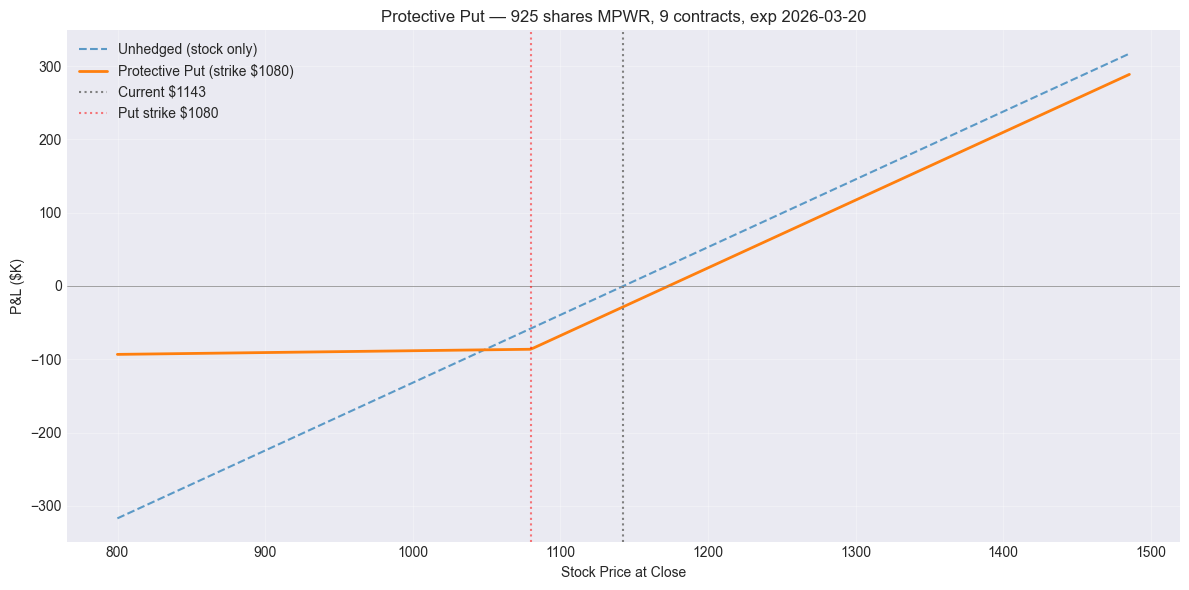

Max loss (hedged):   $-93,341.54  (at stock price $799.92)
Max loss (unhedged): $-317,110.35
Cost of protection:  $28,305.00  (2.68% of position)
Break-even:          $1174.19 (need stock to rise by premium paid)


In [52]:
# Generate range of possible stock prices at expiration
price_range = np.linspace(current_price * 0.70, current_price * 1.30, 300)

def pnl_unhedged(prices, entry_price, shares):
    """P&L of holding stock with no hedge."""
    return (prices - entry_price) * shares

def pnl_protective_put(prices, entry_price, put_strike, put_premium, covered_shares, uncovered_shares):
    """P&L of stock + long put (closed before expiration approximated as intrinsic value)."""
    # Stock P&L on all shares
    stock_pnl = (prices - entry_price) * (covered_shares + uncovered_shares)
    # Put value at expiration (intrinsic) — only on covered shares
    put_value = np.maximum(put_strike - prices, 0)
    put_pnl = (put_value - put_premium) * covered_shares
    return stock_pnl + put_pnl

# Calculate
unhedged = pnl_unhedged(price_range, current_price, SHARES)
hedged_put = pnl_protective_put(price_range, current_price, put_strike, put_cost_per_share, COVERED_SHARES, UNCOVERED_SHARES)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(price_range, unhedged / 1000, label='Unhedged (stock only)', linestyle='--', alpha=0.7)
ax.plot(price_range, hedged_put / 1000, label=f'Protective Put (strike ${put_strike:.0f})', linewidth=2)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=current_price, color='gray', linestyle=':', label=f'Current ${current_price:.0f}')
ax.axvline(x=put_strike, color='red', linestyle=':', alpha=0.5, label=f'Put strike ${put_strike:.0f}')
ax.set_xlabel('Stock Price at Close')
ax.set_ylabel('P&L ($K)')
ax.set_title(f'Protective Put — {SHARES} shares MPWR, {CONTRACTS} contracts, exp {selected_exp}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Key metrics
max_loss_put = hedged_put.min()
print(f"Max loss (hedged):   ${max_loss_put:,.2f}  (at stock price ${price_range[hedged_put.argmin()]:.2f})")
print(f"Max loss (unhedged): ${unhedged.min():,.2f}")
print(f"Cost of protection:  ${put_total_cost:,.2f}  ({put_total_cost / (current_price * SHARES) * 100:.2f}% of position)")
print(f"Break-even:          ${current_price + put_cost_per_share:.2f} (need stock to rise by premium paid)")

## 4. P&L Analysis — Covered Call

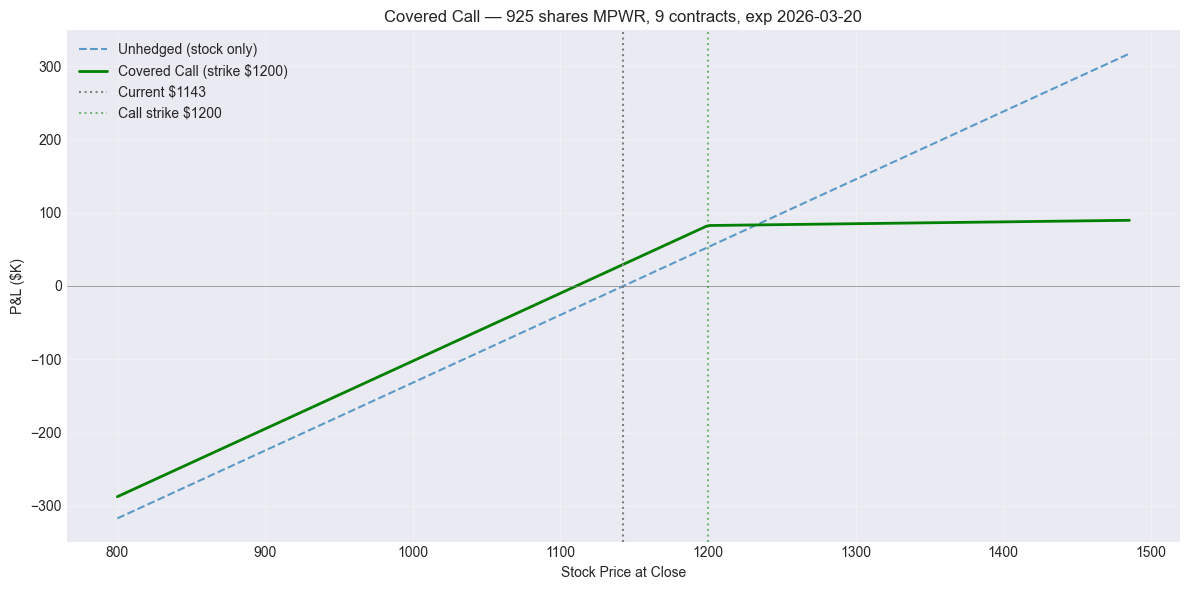

Max gain (capped):   $89,669.56  (stock at or above $1200.00)
Premium income:      $29,565.00
Downside:            No protection — same as unhedged minus premium cushion
Break-even:          $1109.89 (lowered by premium received)


In [53]:
def pnl_covered_call(prices, entry_price, call_strike, call_premium, covered_shares, uncovered_shares):
    """P&L of stock + short call (closed before expiration approximated as intrinsic value)."""
    # Stock P&L on all shares
    stock_pnl = (prices - entry_price) * (covered_shares + uncovered_shares)
    # Short call liability at expiration (intrinsic) — only on covered shares
    call_value = np.maximum(prices - call_strike, 0)
    call_pnl = (call_premium - call_value) * covered_shares
    return stock_pnl + call_pnl

hedged_call = pnl_covered_call(price_range, current_price, call_strike, call_income_per_share, COVERED_SHARES, UNCOVERED_SHARES)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(price_range, unhedged / 1000, label='Unhedged (stock only)', linestyle='--', alpha=0.7)
ax.plot(price_range, hedged_call / 1000, label=f'Covered Call (strike ${call_strike:.0f})', linewidth=2, color='green')
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=current_price, color='gray', linestyle=':', label=f'Current ${current_price:.0f}')
ax.axvline(x=call_strike, color='green', linestyle=':', alpha=0.5, label=f'Call strike ${call_strike:.0f}')
ax.set_xlabel('Stock Price at Close')
ax.set_ylabel('P&L ($K)')
ax.set_title(f'Covered Call — {SHARES} shares MPWR, {CONTRACTS} contracts, exp {selected_exp}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

max_gain_call = hedged_call[price_range >= call_strike].max()
print(f"Max gain (capped):   ${max_gain_call:,.2f}  (stock at or above ${call_strike:.2f})")
print(f"Premium income:      ${call_total_income:,.2f}")
print(f"Downside:            No protection — same as unhedged minus premium cushion")
print(f"Break-even:          ${current_price - call_income_per_share:.2f} (lowered by premium received)")

## 5. P&L Analysis — Collar

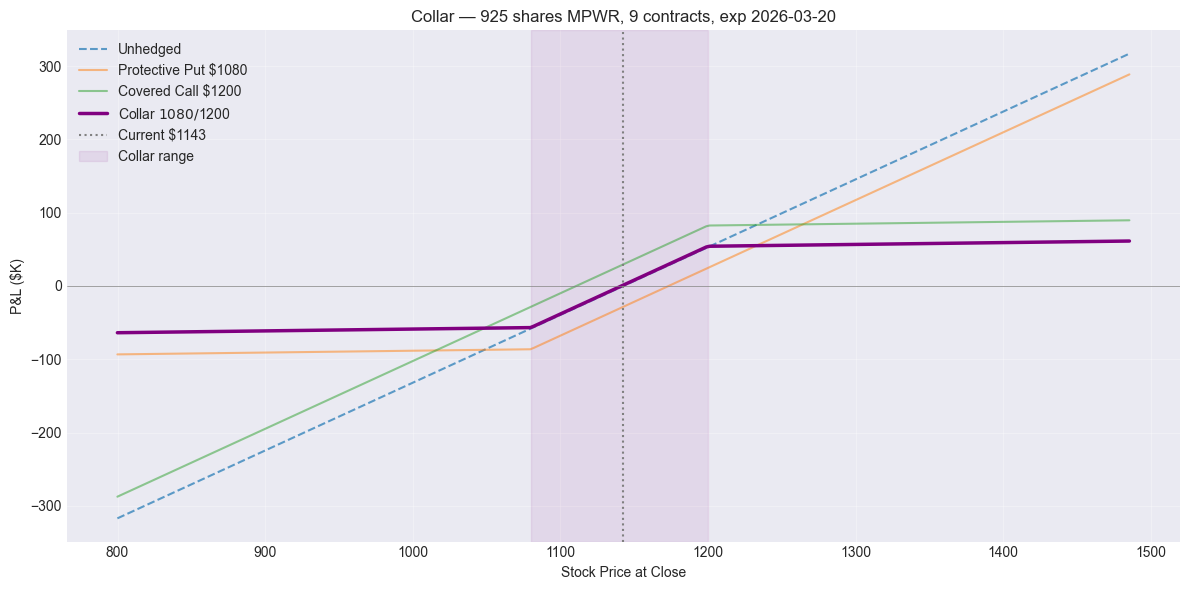

=== Collar Summary ===
Put strike (floor):  $1080.00
Call strike (cap):   $1200.00
Net credit:           $1.40/share ($1,260.00 total)
Max loss (hedged):   $-63,776.54
Max gain (capped):   $61,364.56

Note: 25 uncovered shares have unlimited upside and downside beyond the collar range.


In [54]:
def pnl_collar(prices, entry_price, put_strike, put_premium, call_strike, call_premium, covered_shares, uncovered_shares):
    """P&L of stock + long put + short call (both closed before expiration, approx intrinsic)."""
    stock_pnl = (prices - entry_price) * (covered_shares + uncovered_shares)
    put_value = np.maximum(put_strike - prices, 0)
    put_pnl = (put_value - put_premium) * covered_shares
    call_value = np.maximum(prices - call_strike, 0)
    call_pnl = (call_premium - call_value) * covered_shares
    return stock_pnl + put_pnl + call_pnl

hedged_collar = pnl_collar(
    price_range, current_price,
    put_strike, put_cost_per_share,
    call_strike, call_income_per_share,
    COVERED_SHARES, UNCOVERED_SHARES
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(price_range, unhedged / 1000, label='Unhedged', linestyle='--', alpha=0.7)
ax.plot(price_range, hedged_put / 1000, label=f'Protective Put ${put_strike:.0f}', alpha=0.5)
ax.plot(price_range, hedged_call / 1000, label=f'Covered Call ${call_strike:.0f}', alpha=0.5)
ax.plot(price_range, hedged_collar / 1000, label=f'Collar ${put_strike:.0f}/${call_strike:.0f}', linewidth=2.5, color='purple')
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=current_price, color='gray', linestyle=':', label=f'Current ${current_price:.0f}')
ax.axvspan(put_strike, call_strike, alpha=0.08, color='purple', label='Collar range')
ax.set_xlabel('Stock Price at Close')
ax.set_ylabel('P&L ($K)')
ax.set_title(f'Collar — {SHARES} shares MPWR, {CONTRACTS} contracts, exp {selected_exp}')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Key collar metrics
max_loss_collar = hedged_collar.min()
max_gain_collar = hedged_collar.max()
print(f"=== Collar Summary ===")
print(f"Put strike (floor):  ${put_strike:.2f}")
print(f"Call strike (cap):   ${call_strike:.2f}")
collar_label2 = 'Net cost' if collar_net_per_share > 0 else 'Net credit'
print(f"{collar_label2}:           ${abs(collar_net_per_share):.2f}/share (${abs(collar_net_total):,.2f} total)")
print(f"Max loss (hedged):   ${max_loss_collar:,.2f}")
print(f"Max gain (capped):   ${max_gain_collar:,.2f}")
print(f"")
print(f"Note: 25 uncovered shares have unlimited upside and downside beyond the collar range.")

## 6. Strategy Comparison Table

Strategy Comparison — MPWR @ $1142.74, exp 2026-03-20
Put: $1080 @ $31.45 | Call: $1200 @ $32.85

Scenario     Price  Unhedged Prot. Put Cov. Call   Collar Collar Edge
    -30%   $799.92 $-317,110  $-93,342 $-287,545 $-63,777    $253,334
    -20%   $914.19 $-211,407  $-90,485 $-181,842 $-60,920    $150,487
    -10% $1,028.47 $-105,703  $-87,628  $-76,138 $-58,063     $47,641
    Flat $1,142.74        $0  $-28,305   $29,565   $1,260      $1,260
    +10% $1,257.01  $105,703   $77,398   $83,956  $55,651    $-50,053
    +20% $1,371.29  $211,407  $183,102   $86,813  $58,508   $-152,899
    +30% $1,485.56  $317,110  $288,805   $89,670  $61,365   $-255,746

Collar Edge = Collar P&L minus Unhedged P&L (positive = collar outperforms)


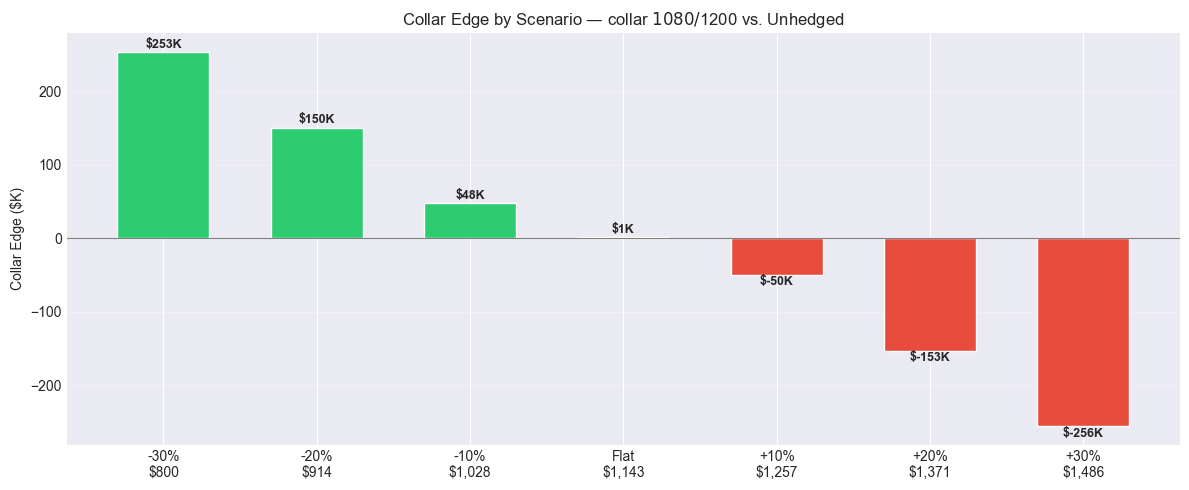

In [55]:
# Compare strategies at key price points
scenarios = {
    '-30%': current_price * 0.70,
    '-20%': current_price * 0.80,
    '-10%': current_price * 0.90,
    'Flat': current_price,
    '+10%': current_price * 1.10,
    '+20%': current_price * 1.20,
    '+30%': current_price * 1.30,
}

rows = []
scenario_labels = []
scenario_prices = []
collar_edges = []

for label, price in scenarios.items():
    p = np.array([price])
    unhedged_val = pnl_unhedged(p, current_price, SHARES)[0]
    collar_val = pnl_collar(p, current_price, put_strike, put_cost_per_share, call_strike, call_income_per_share, COVERED_SHARES, UNCOVERED_SHARES)[0]
    edge = collar_val - unhedged_val
    scenario_labels.append(label)
    scenario_prices.append(price)
    collar_edges.append(edge)
    rows.append({
        'Scenario': label,
        'Price': f'${price:,.2f}',
        'Unhedged': f'${unhedged_val:,.0f}',
        'Prot. Put': f'${pnl_protective_put(p, current_price, put_strike, put_cost_per_share, COVERED_SHARES, UNCOVERED_SHARES)[0]:,.0f}',
        'Cov. Call': f'${pnl_covered_call(p, current_price, call_strike, call_income_per_share, COVERED_SHARES, UNCOVERED_SHARES)[0]:,.0f}',
        'Collar': f'${collar_val:,.0f}',
        'Collar Edge': f'${edge:,.0f}',
    })

comparison = pd.DataFrame(rows)
print(f"Strategy Comparison — MPWR @ ${current_price:.2f}, exp {selected_exp}")
print(f"Put: ${put_strike:.0f} @ ${put_cost_per_share:.2f} | Call: ${call_strike:.0f} @ ${call_income_per_share:.2f}")
print()
print(comparison.to_string(index=False))
print()
print("Collar Edge = Collar P&L minus Unhedged P&L (positive = collar outperforms)")

# --- Collar Edge chart ---
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2ecc71' if e >= 0 else '#e74c3c' for e in collar_edges]
bars = ax.bar(range(len(scenario_labels)), [e / 1000 for e in collar_edges], color=colors, edgecolor='white', width=0.6)

# Label each bar with the dollar value
for i, (bar, edge) in enumerate(zip(bars, collar_edges)):
    va = 'bottom' if edge >= 0 else 'top'
    offset = 2 if edge >= 0 else -2
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + offset,
            f'${edge / 1000:,.0f}K', ha='center', va=va, fontsize=9, fontweight='bold')

# X-axis: scenario + price on two lines
x_labels = [f'{lbl}\n${p:,.0f}' for lbl, p in zip(scenario_labels, scenario_prices)]
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, fontsize=10)

ax.axhline(y=0, color='gray', linewidth=0.8)
ax.set_ylabel('Collar Edge ($K)')
ax.set_title(f'Collar Edge by Scenario — collar ${put_strike:.0f}/${call_strike:.0f} vs. Unhedged')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Explore Different Strikes

Scan across put/call strike combinations to find optimal collars.

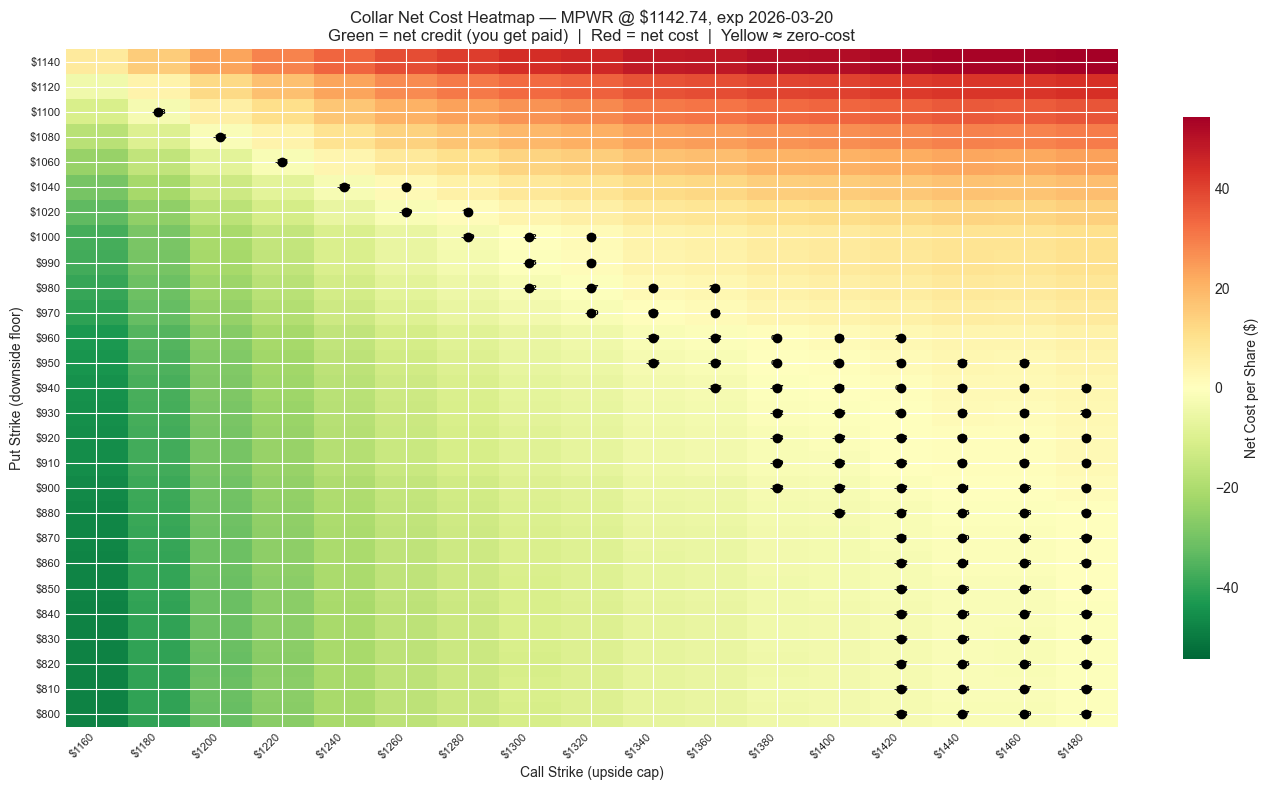

Black dots = near zero-cost collars (|net cost| ≤ $3/share)

=== Top 15 Near Zero-Cost Collars (sorted by |net cost|) ===
MPWR @ $1142.74, exp 2026-03-20

 put_strike  put_prem  call_strike  call_prem  net_per_share  net_total  put_otm_pct  call_otm_pct
     870.00      1.52      1480.00       1.53          -0.00      -0.00        23.87         29.51
     950.00      5.20      1380.00       5.15           0.05      45.00        16.87         20.76
     860.00      1.45      1480.00       1.53          -0.08     -67.50        24.74         29.51
     940.00      4.45      1400.00       4.55          -0.10     -90.00        17.74         22.51
     900.00      2.38      1440.00       2.50          -0.12    -112.50        21.24         26.01
    1000.00     11.75      1300.00      11.95          -0.20    -180.00        12.49         13.76
     920.00      3.33      1420.00       3.62          -0.30    -270.00        19.49         24.26
     930.00      3.92      1420.00       3.62        

In [56]:
# Scan collar combinations: vary put and call strikes
# Focus on OTM puts (below current) and OTM calls (above current)
otm_puts = puts[puts['strike'] < current_price].copy()
otm_calls = calls[calls['strike'] > current_price].copy()

collar_scan = []
for _, p in otm_puts.iterrows():
    p_strike = p['strike']
    p_mid = (p['bid'] + p['ask']) / 2
    if p_mid == 0:
        p_mid = p['lastPrice']
    for _, c in otm_calls.iterrows():
        c_strike = c['strike']
        c_mid = (c['bid'] + c['ask']) / 2
        if c_mid == 0:
            c_mid = c['lastPrice']
        net = p_mid - c_mid  # positive = net cost, negative = net credit
        collar_scan.append({
            'put_strike': p_strike,
            'put_prem': p_mid,
            'call_strike': c_strike,
            'call_prem': c_mid,
            'net_per_share': net,
            'net_total': net * COVERED_SHARES,
            'put_otm_pct': (current_price - p_strike) / current_price * 100,
            'call_otm_pct': (c_strike - current_price) / current_price * 100,
            'protection_width': c_strike - p_strike,
        })

scan_df = pd.DataFrame(collar_scan)

# --- Heatmap: net cost by put strike vs call strike ---
pivot = scan_df.pivot_table(index='put_strike', columns='call_strike', values='net_per_share')
pivot = pivot.sort_index(ascending=False)  # higher put strikes at top

fig, ax = plt.subplots(figsize=(14, 8))
max_abs = max(abs(scan_df['net_per_share'].min()), abs(scan_df['net_per_share'].max()))
im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto',
               vmin=-max_abs, vmax=max_abs)

# Axis labels
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'${s:.0f}' for s in pivot.columns], rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'${s:.0f}' for s in pivot.index], fontsize=8)
ax.set_xlabel('Call Strike (upside cap)')
ax.set_ylabel('Put Strike (downside floor)')
ax.set_title(f'Collar Net Cost Heatmap — MPWR @ ${current_price:.2f}, exp {selected_exp}\n'
             f'Green = net credit (you get paid)  |  Red = net cost  |  Yellow ≈ zero-cost')

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Net Cost per Share ($)', fontsize=10)

# Mark near-zero-cost cells with a dot
for i, put_s in enumerate(pivot.index):
    for j, call_s in enumerate(pivot.columns):
        val = pivot.iloc[i, j]
        if not np.isnan(val) and abs(val) <= 3.0:
            ax.plot(j, i, 'ko', markersize=6)
            ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=6, fontweight='bold', color='black')

plt.tight_layout()
plt.show()
print("Black dots = near zero-cost collars (|net cost| ≤ $3/share)")

# --- Table of best near-zero-cost collars ---
scan_df['abs_net'] = scan_df['net_per_share'].abs()
near_zero = scan_df.nsmallest(15, 'abs_net')

print(f"\n=== Top 15 Near Zero-Cost Collars (sorted by |net cost|) ===")
print(f"MPWR @ ${current_price:.2f}, exp {selected_exp}\n")
display_cols = ['put_strike', 'put_prem', 'call_strike', 'call_prem', 'net_per_share', 'net_total', 'put_otm_pct', 'call_otm_pct']
print(near_zero[display_cols].to_string(index=False, float_format='%.2f'))

## 8. Dividend Impact

How does the quarterly dividend income offset the cost of protection?

In [57]:
print(f"=== Dividend vs. Hedge Cost ===")
print(f"Quarterly dividend income: ${QUARTERLY_DIVIDEND_INCOME:,.2f} ({SHARES} x ${QUARTERLY_DIVIDEND_PER_SHARE})")
print()
print(f"Protective put cost:       ${put_total_cost:,.2f}")
print(f"  Dividend covers:         {QUARTERLY_DIVIDEND_INCOME / put_total_cost * 100:.1f}% of put cost")
print()
if collar_net_total > 0:
    print(f"Collar net cost:           ${collar_net_total:,.2f}")
    print(f"  Dividend covers:         {QUARTERLY_DIVIDEND_INCOME / collar_net_total * 100:.1f}% of collar cost")
else:
    print(f"Collar net CREDIT:         ${abs(collar_net_total):,.2f}")
    print(f"  Collar pays you + dividend income of ${QUARTERLY_DIVIDEND_INCOME:,.2f}")
print()
print(f"Covered call income:       ${call_total_income:,.2f}")
print(f"  + dividend:              ${call_total_income + QUARTERLY_DIVIDEND_INCOME:,.2f} total quarterly income")

=== Dividend vs. Hedge Cost ===
Quarterly dividend income: $1,443.00 (925 x $1.56)

Protective put cost:       $28,305.00
  Dividend covers:         5.1% of put cost

Collar net CREDIT:         $1,260.00
  Collar pays you + dividend income of $1,443.00

Covered call income:       $29,565.00
  + dividend:              $31,008.00 total quarterly income


## 9. Custom Scenario — Enter Your Own Strikes

Edit the two strike values below and re-run the cell. The premium is auto-looked up from the options chain.

**Examples:**
- `custom_put_strike = 1050` — deeper OTM put (cheaper, less protection)
- `custom_call_strike = 1400` — higher cap (more upside, less income)
- Or pick a pair from the Section 7 collar scan table above

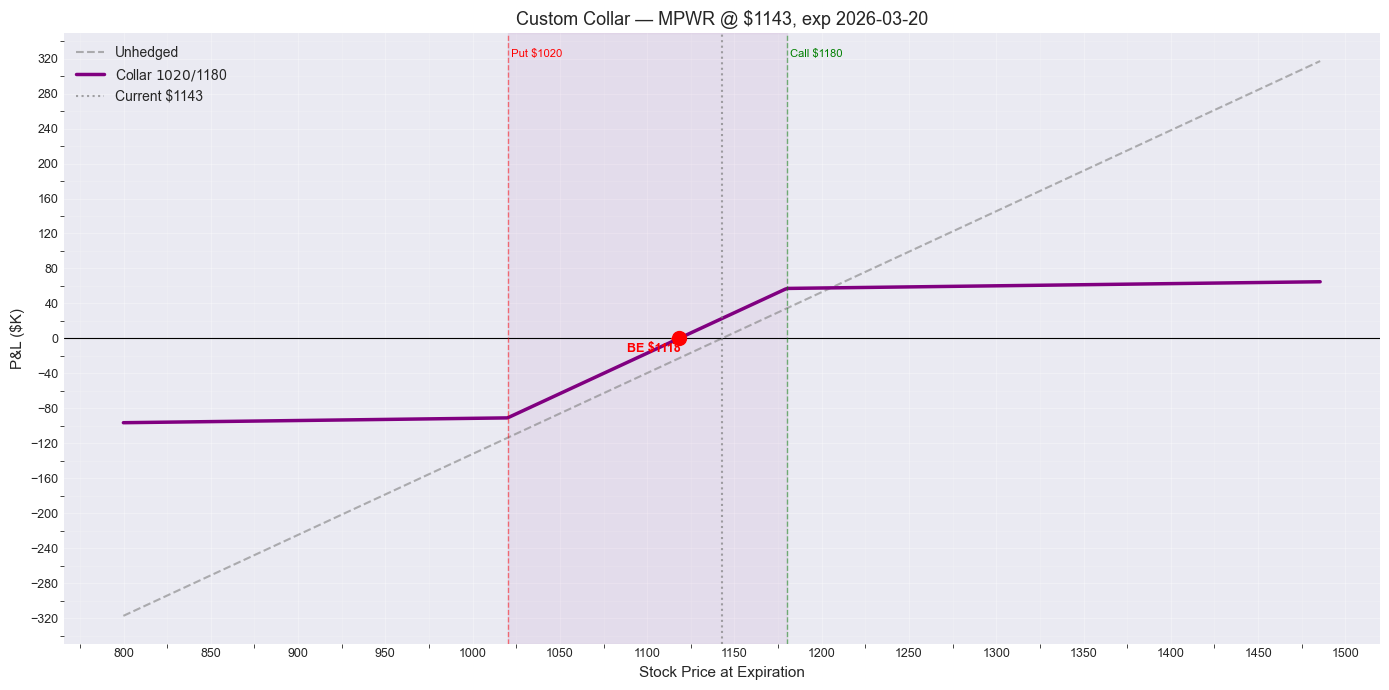

  Custom Collar Summary — MPWR @ $1142.74
  Expiration:        2026-03-20
  Put strike:        $1020.00  (premium: $15.75)
  Call strike:       $1180.00  (premium: $41.00)
  Protection width:  $160  (1020 to 1180)

  Net credit:        $25.25/share  ($22,725.00 total)
  Max loss:          $-96,311.54
  Max gain:          $64,829.56

  Downside break-even: $1,118.17  (2.1% below current)
  Upside break-even:   N/A (no upside crossover in range)

  Scenario Table — Custom Collar vs. Unhedged
  Put: $1020 @ $15.75 | Call: $1180 @ $41.00

Scenario     Price  Unhedged   Collar Collar Edge
    -30%   $799.92 $-317,110 $-96,312    $220,799
    -25%   $857.05 $-264,259 $-94,883    $169,376
    -20%   $914.19 $-211,407 $-93,455    $117,952
    -15%   $971.33 $-158,555 $-92,026     $66,529
    -10% $1,028.47 $-105,703 $-82,978     $22,725
     -5% $1,085.60  $-52,852 $-30,127     $22,725
    Flat $1,142.74        $0  $22,725     $22,725
     +5% $1,199.88   $52,852  $57,687      $4,836
    +10% 

In [58]:
# === CUSTOM SCENARIO — edit these two values, then run this cell ===
custom_put_strike = 1020    # <-- change this to your desired put strike
custom_call_strike = 1180   # <-- change this to your desired call strike

# Auto-lookup premium from the options chain (snaps to nearest available strike)
_p_row = puts.iloc[(puts['strike'] - custom_put_strike).abs().argsort()[:1]]
custom_put_strike = _p_row['strike'].values[0]
custom_put_premium = (_p_row['bid'].values[0] + _p_row['ask'].values[0]) / 2
if custom_put_premium == 0:
    custom_put_premium = _p_row['lastPrice'].values[0]

_c_row = calls.iloc[(calls['strike'] - custom_call_strike).abs().argsort()[:1]]
custom_call_strike = _c_row['strike'].values[0]
custom_call_premium = (_c_row['bid'].values[0] + _c_row['ask'].values[0]) / 2
if custom_call_premium == 0:
    custom_call_premium = _c_row['lastPrice'].values[0]

# Price range: ±30% from current price (matches scenario table)
plot_low = current_price * 0.70
plot_high = current_price * 1.30
custom_price_range = np.linspace(plot_low, plot_high, 500)

# Calculate P&L on the range
custom_collar = pnl_collar(
    custom_price_range, current_price,
    custom_put_strike, custom_put_premium,
    custom_call_strike, custom_call_premium,
    COVERED_SHARES, UNCOVERED_SHARES
)
custom_unhedged = pnl_unhedged(custom_price_range, current_price, SHARES)

net = custom_put_premium - custom_call_premium
net_total = net * COVERED_SHARES

# Find break-even prices (where collar P&L crosses zero)
breakevens = []
for i in range(1, len(custom_collar)):
    if custom_collar[i-1] * custom_collar[i] < 0:  # sign change
        # Linear interpolation
        x0, x1 = custom_price_range[i-1], custom_price_range[i]
        y0, y1 = custom_collar[i-1], custom_collar[i]
        be = x0 - y0 * (x1 - x0) / (y1 - y0)
        breakevens.append(be)

downside_be = min(breakevens) if breakevens else None
upside_be = max(breakevens) if len(breakevens) > 1 else None

# --- Chart ---
from matplotlib.ticker import MultipleLocator

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(custom_price_range, custom_unhedged / 1000, label='Unhedged', linestyle='--', alpha=0.6, color='gray')
ax.plot(custom_price_range, custom_collar / 1000,
        label=f'Collar ${custom_put_strike:.0f}/${custom_call_strike:.0f}', linewidth=2.5, color='purple')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.axvline(x=current_price, color='gray', linestyle=':', alpha=0.7, label=f'Current ${current_price:.0f}')
ax.axvspan(custom_put_strike, custom_call_strike, alpha=0.06, color='purple')

# Mark put and call strikes
ax.axvline(x=custom_put_strike, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(x=custom_call_strike, color='green', linestyle='--', alpha=0.5, linewidth=1)
ax.text(custom_put_strike, ax.get_ylim()[1] * 0.95, f' Put ${custom_put_strike:.0f}',
        color='red', fontsize=8, va='top')
ax.text(custom_call_strike, ax.get_ylim()[1] * 0.95, f' Call ${custom_call_strike:.0f}',
        color='green', fontsize=8, va='top')

# Mark break-even points
if downside_be:
    ax.plot(downside_be, 0, 'ro', markersize=10, zorder=5)
    ax.annotate(f'BE ${downside_be:.0f}', xy=(downside_be, 0),
                xytext=(downside_be - 30, -15), fontsize=9, fontweight='bold', color='red',
                arrowprops=dict(arrowstyle='->', color='red', lw=1.2))
if upside_be:
    ax.plot(upside_be, 0, 'go', markersize=10, zorder=5)
    ax.annotate(f'BE ${upside_be:.0f}', xy=(upside_be, 0),
                xytext=(upside_be + 10, -15), fontsize=9, fontweight='bold', color='green',
                arrowprops=dict(arrowstyle='->', color='green', lw=1.2))

# X-axis: more ticks, every $50
x_major = MultipleLocator(50)
x_minor = MultipleLocator(25)
ax.xaxis.set_major_locator(x_major)
ax.xaxis.set_minor_locator(x_minor)
ax.tick_params(axis='x', which='major', labelsize=9)
ax.tick_params(axis='x', which='minor', length=3)
ax.set_xlabel('Stock Price at Expiration', fontsize=11)

# Y-axis: more ticks
y_range = (custom_collar.min() / 1000, max(custom_collar.max(), custom_unhedged.max()) / 1000)
y_span = y_range[1] - y_range[0]
y_major_step = max(10, round(y_span / 10 / 5) * 5)  # round to nearest 5K
y_minor_step = y_major_step / 2
ax.yaxis.set_major_locator(MultipleLocator(y_major_step))
ax.yaxis.set_minor_locator(MultipleLocator(y_minor_step))
ax.tick_params(axis='y', which='major', labelsize=9)
ax.tick_params(axis='y', which='minor', length=3)
ax.set_ylabel('P&L ($K)', fontsize=11)

ax.set_title(f'Custom Collar — MPWR @ ${current_price:.0f}, exp {selected_exp}', fontsize=13)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, which='major', alpha=0.3)
ax.grid(True, which='minor', alpha=0.15)
plt.tight_layout()
plt.show()

# --- Detailed output ---
print(f"{'='*65}")
print(f"  Custom Collar Summary — MPWR @ ${current_price:.2f}")
print(f"{'='*65}")
print(f"  Expiration:        {selected_exp}")
print(f"  Put strike:        ${custom_put_strike:.2f}  (premium: ${custom_put_premium:.2f})")
print(f"  Call strike:       ${custom_call_strike:.2f}  (premium: ${custom_call_premium:.2f})")
print(f"  Protection width:  ${custom_call_strike - custom_put_strike:.0f}  "
      f"({custom_put_strike:.0f} to {custom_call_strike:.0f})")
print()
collar_label = 'Net cost' if net > 0 else 'Net credit'
print(f"  {collar_label}:        ${abs(net):.2f}/share  (${abs(net_total):,.2f} total)")
print(f"  Max loss:          ${custom_collar.min():,.2f}")
print(f"  Max gain:          ${custom_collar.max():,.2f}")
print()
if downside_be:
    down_pct = (current_price - downside_be) / current_price * 100
    print(f"  Downside break-even: ${downside_be:,.2f}  ({down_pct:.1f}% below current)")
else:
    print(f"  Downside break-even: N/A (collar is profitable at all lower prices shown)")
if upside_be:
    up_pct = (upside_be - current_price) / current_price * 100
    print(f"  Upside break-even:   ${upside_be:,.2f}  ({up_pct:.1f}% above current)")
else:
    if len(breakevens) == 1:
        print(f"  Upside break-even:   N/A (no upside crossover in range)")
    else:
        print(f"  Upside break-even:   N/A")
print(f"{'='*65}")

# --- Scenario Table (5% increments, ±30%) ---
print(f"\n{'='*65}")
print(f"  Scenario Table — Custom Collar vs. Unhedged")
print(f"{'='*65}")

custom_scenarios = {}
for pct in range(-30, 35, 5):
    if pct < 0:
        label = f'{pct}%'
    elif pct == 0:
        label = 'Flat'
    else:
        label = f'+{pct}%'
    custom_scenarios[label] = current_price * (1 + pct / 100)

s_rows = []
for label, price in custom_scenarios.items():
    p = np.array([price])
    u_val = pnl_unhedged(p, current_price, SHARES)[0]
    c_val = pnl_collar(p, current_price, custom_put_strike, custom_put_premium,
                       custom_call_strike, custom_call_premium, COVERED_SHARES, UNCOVERED_SHARES)[0]
    edge = c_val - u_val
    s_rows.append({
        'Scenario': label,
        'Price': f'${price:,.2f}',
        'Unhedged': f'${u_val:,.0f}',
        'Collar': f'${c_val:,.0f}',
        'Collar Edge': f'${edge:,.0f}',
    })

s_df = pd.DataFrame(s_rows)
print(f"  Put: ${custom_put_strike:.0f} @ ${custom_put_premium:.2f} | "
      f"Call: ${custom_call_strike:.0f} @ ${custom_call_premium:.2f}\n")
print(s_df.to_string(index=False))
print(f"\n  Collar Edge = Collar P&L minus Unhedged P&L (positive = collar outperforms)")
print(f"{'='*65}")

## 10. Call Roll-Up Strategy

Model rolling up a covered call as the stock price increases. At each roll:
1. **Buy back** the current short call (now deeper ITM) at its intrinsic value + estimated remaining time value
2. **Sell a new call** at a higher strike, collecting fresh premium

The goal is to see whether the original call premium plus subsequent roll credits/debits
allow you to keep raising the upside cap as the stock appreciates.

**Edit the roll steps below** to model your scenario — each step is `(stock_price_when_you_roll, new_call_strike)`.
The model uses intrinsic value + an adjustable time-value buffer for buyback cost,
and looks up the new call premium from the current options chain.

  Call Roll-Up Model -- MPWR @ $1142.74, exp 2026-03-20
  Starting position: Short 9 calls @ $1180
  Initial premium received: $41.00/share  ($36,900.00 total)
  Time-value buffer for buybacks: 2.0% of stock price

  Roll-by-Roll Detail:

   Step Stock Price                          Action Buyback Cost New Premium Roll Net/Share Roll Net Total Cumul. Cash New Cap
Initial    $1142.74                 Sell 9C @ $1180           --      $41.00        +$41.00    +$36,900.00  $36,900.00   $1180
 Roll 1    $1199.88 Buy 9C @ $1180, Sell 9C @ $1260       $43.87      $17.70        $-26.17    $-23,557.08  $13,342.92   $1260
 Roll 2    $1257.01 Buy 9C @ $1260, Sell 9C @ $1320       $25.14      $10.45        $-14.69    $-13,221.25     $121.67   $1320
 Roll 3    $1314.15 Buy 9C @ $1320, Sell 9C @ $1380       $26.28       $5.15        $-21.13    $-19,019.72 $-18,898.05   $1380

  ------------------------------------------------------------
  Net cash flow after all rolls: -$18,898.05  (net debit)
  Th

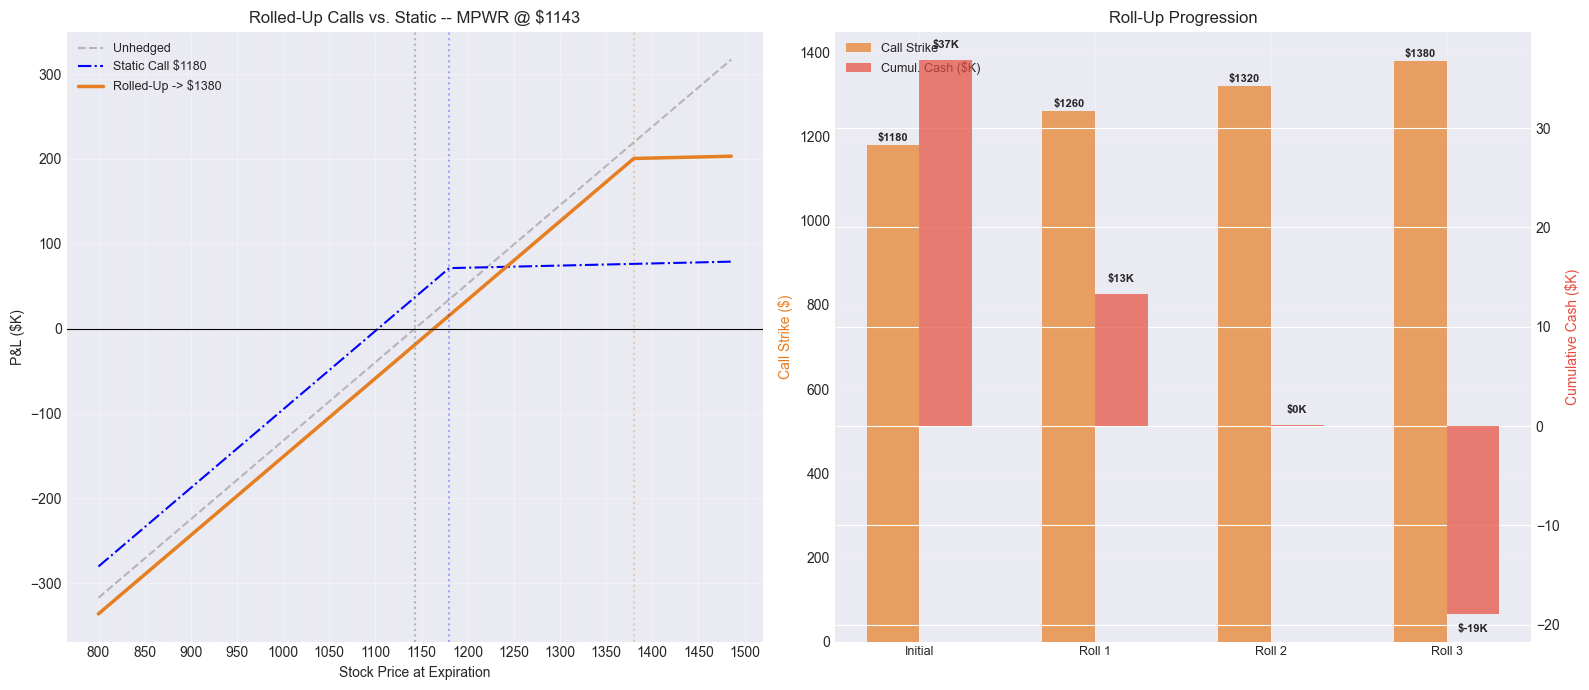


  Terminal P&L Comparison -- Rolled-Up vs. Static vs. Unhedged
  Static call: $1180 @ $41.00
  Rolled-up to: $1380  |  Cumul. cash: $-18,898.05

Scenario     Price  Unhedged Static CC Rolled CC Roll Benefit
    -20%   $914.19 $-211,407 $-174,507 $-230,305     $-55,798
    -15%   $971.33 $-158,555 $-121,655 $-177,453     $-55,798
    -10% $1,028.47 $-105,703  $-68,803 $-124,601     $-55,798
     -5% $1,085.60  $-52,852  $-15,952  $-71,750     $-55,798
    Flat $1,142.74        $0   $36,900  $-18,898     $-55,798
     +5% $1,199.88   $52,852   $71,862   $33,954     $-37,909
    +10% $1,257.01  $105,703   $73,291   $86,805      $13,515
    +15% $1,314.15  $158,555   $74,719  $139,657      $64,938
    +20% $1,371.29  $211,407   $76,148  $192,509     $116,361
    +25% $1,428.42  $264,259   $77,576  $201,778     $124,202
    +30% $1,485.56  $317,110   $79,005  $203,207     $124,202

  Roll Benefit = Rolled CC P&L minus Static CC P&L


In [59]:
# === CALL ROLL-UP MODEL ===
# Edit these roll steps to model your scenario.
# Each tuple: (stock_price_when_you_roll, new_call_strike)
# The model starts from the covered call in Section 9.

initial_strike = custom_call_strike          # starting call strike from Section 9
initial_premium = custom_call_premium        # premium received when originally sold

# Time-value buffer: when buying back an ITM call, the actual cost is
# intrinsic value + remaining time value.  Adjust this % to be conservative.
time_value_pct = 0.02   # estimated remaining time value as % of stock price

# --- Define your roll-up steps here ---
# Format: (stock_price_at_time_of_roll, new_call_strike_to_sell)
roll_steps = [
    (current_price * 1.05, round(current_price * 1.10)),   # stock up ~5%, roll to ~10% OTM from entry
    (current_price * 1.10, round(current_price * 1.15)),   # stock up ~10%, roll to ~15% OTM
    (current_price * 1.15, round(current_price * 1.20)),   # stock up ~15%, roll to ~20% OTM
]

# =====================================================================
# MODEL EXECUTION -- no edits needed below
# =====================================================================

def lookup_call_premium(strike, calls_df):
    """Look up mid-price for a call strike from the chain (snaps to nearest)."""
    row = calls_df.iloc[(calls_df['strike'] - strike).abs().argsort()[:1]]
    actual_strike = row['strike'].values[0]
    mid = (row['bid'].values[0] + row['ask'].values[0]) / 2
    if mid == 0:
        mid = row['lastPrice'].values[0]
    return actual_strike, mid

def estimate_buyback_cost(stock_price, short_strike, tv_pct):
    """Estimate cost to buy back a short call: intrinsic + time value."""
    intrinsic = max(stock_price - short_strike, 0)
    time_value = stock_price * tv_pct
    return intrinsic + time_value

# --- Process rolls ---
print(f"{'='*75}")
print(f"  Call Roll-Up Model -- MPWR @ ${current_price:.2f}, exp {selected_exp}")
print(f"{'='*75}")
print(f"  Starting position: Short {CONTRACTS} calls @ ${initial_strike:.0f}")
print(f"  Initial premium received: ${initial_premium:.2f}/share  (${initial_premium * COVERED_SHARES:,.2f} total)")
print(f"  Time-value buffer for buybacks: {time_value_pct:.1%} of stock price")
print()

current_short_strike = initial_strike
cumulative_cash = initial_premium * COVERED_SHARES  # start with initial premium received
roll_log = []  # track each roll for charting

# Log initial position
roll_log.append({
    'Step': 'Initial',
    'Stock Price': f'${current_price:.2f}',
    'Action': f'Sell {CONTRACTS}C @ ${initial_strike:.0f}',
    'Buyback Cost': '--',
    'New Premium': f'${initial_premium:.2f}',
    'Roll Net/Share': f'+${initial_premium:.2f}',
    'Roll Net Total': f'+${initial_premium * COVERED_SHARES:,.2f}',
    'Cumul. Cash': f'${cumulative_cash:,.2f}',
    'New Cap': f'${initial_strike:.0f}',
    '_strike': initial_strike,
    '_stock_price': current_price,
    '_cumul': cumulative_cash,
})

for i, (roll_price, new_strike) in enumerate(roll_steps, 1):
    # Snap new strike to nearest available in chain
    actual_new_strike, new_prem = lookup_call_premium(new_strike, calls)

    # Cost to buy back the current short call
    buyback = estimate_buyback_cost(roll_price, current_short_strike, time_value_pct)

    # Net cash flow for this roll
    roll_net_per_share = new_prem - buyback
    roll_net_total = roll_net_per_share * COVERED_SHARES
    cumulative_cash += roll_net_total

    roll_log.append({
        'Step': f'Roll {i}',
        'Stock Price': f'${roll_price:.2f}',
        'Action': f'Buy {CONTRACTS}C @ ${current_short_strike:.0f}, Sell {CONTRACTS}C @ ${actual_new_strike:.0f}',
        'Buyback Cost': f'${buyback:.2f}',
        'New Premium': f'${new_prem:.2f}',
        'Roll Net/Share': f'{"+" if roll_net_per_share >= 0 else ""}${roll_net_per_share:.2f}',
        'Roll Net Total': f'{"+" if roll_net_total >= 0 else ""}${roll_net_total:,.2f}',
        'Cumul. Cash': f'${cumulative_cash:,.2f}',
        'New Cap': f'${actual_new_strike:.0f}',
        '_strike': actual_new_strike,
        '_stock_price': roll_price,
        '_cumul': cumulative_cash,
    })

    current_short_strike = actual_new_strike

final_strike = current_short_strike

# --- Roll Summary Table ---
display_cols = ['Step', 'Stock Price', 'Action', 'Buyback Cost', 'New Premium',
                'Roll Net/Share', 'Roll Net Total', 'Cumul. Cash', 'New Cap']
roll_df = pd.DataFrame(roll_log)
print("  Roll-by-Roll Detail:")
print()
print(roll_df[display_cols].to_string(index=False))
print()

# Cumulative assessment
print(f"  {'-'*60}")
if cumulative_cash >= 0:
    print(f"  Net cash flow after all rolls: +${cumulative_cash:,.2f}  (net credit)")
    print(f"  The original premium FULLY funded all roll-ups.")
else:
    print(f"  Net cash flow after all rolls: -${abs(cumulative_cash):,.2f}  (net debit)")
    print(f"  The roll-ups cost ${abs(cumulative_cash):,.2f} more than the original premium.")
print(f"  Upside cap raised from ${initial_strike:.0f} -> ${final_strike:.0f}  "
      f"(+${final_strike - initial_strike:.0f}, +{(final_strike - initial_strike) / initial_strike * 100:.1f}%)")
print(f"  {'-'*60}")

# --- Comparison Chart: Rolled-Up vs Static Covered Call vs Unhedged ---
comp_range = np.linspace(current_price * 0.70, current_price * 1.30, 500)

# Static covered call (original strike, never rolled)
static_cc = pnl_covered_call(comp_range, current_price, initial_strike,
                              initial_premium, COVERED_SHARES, UNCOVERED_SHARES)

# Rolled-up covered call:
# - Stock P&L on all shares
# - Capped at final_strike on covered shares
# - Cumulative cash from all premiums/buybacks
rolled_stock_pnl = (np.minimum(comp_range, final_strike) - current_price) * COVERED_SHARES \
                 + (comp_range - current_price) * UNCOVERED_SHARES
rolled_cc = rolled_stock_pnl + cumulative_cash

unhedged_comp = pnl_unhedged(comp_range, current_price, SHARES)

from matplotlib.ticker import MultipleLocator

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- Left panel: P&L comparison ---
ax1.plot(comp_range, unhedged_comp / 1000, label='Unhedged', linestyle='--', alpha=0.5, color='gray')
ax1.plot(comp_range, static_cc / 1000, label=f'Static Call ${initial_strike:.0f}',
         linestyle='-.', linewidth=1.5, color='blue')
ax1.plot(comp_range, rolled_cc / 1000, label=f'Rolled-Up -> ${final_strike:.0f}',
         linewidth=2.5, color='#e67e22')
ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.axvline(x=current_price, color='gray', linestyle=':', alpha=0.5)

# Mark the strike caps
ax1.axvline(x=initial_strike, color='blue', linestyle=':', alpha=0.3)
ax1.axvline(x=final_strike, color='#e67e22', linestyle=':', alpha=0.3)

x_major = MultipleLocator(50)
x_minor = MultipleLocator(25)
ax1.xaxis.set_major_locator(x_major)
ax1.xaxis.set_minor_locator(x_minor)
ax1.set_xlabel('Stock Price at Expiration')
ax1.set_ylabel('P&L ($K)')
ax1.set_title(f'Rolled-Up Calls vs. Static -- MPWR @ ${current_price:.0f}')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, which='major', alpha=0.3)
ax1.grid(True, which='minor', alpha=0.15)

# --- Right panel: Strike cap & cumulative cash flow by roll step ---
steps = list(range(len(roll_log)))
strikes = [r['_strike'] for r in roll_log]
cumuls = [r['_cumul'] for r in roll_log]
step_labels = [r['Step'] for r in roll_log]

color_strikes = '#e67e22'
color_cash = '#2ecc71' if cumulative_cash >= 0 else '#e74c3c'

ax2_twin = ax2.twinx()

bars = ax2.bar([s - 0.15 for s in steps], strikes, width=0.3, color=color_strikes,
               alpha=0.7, label='Call Strike')
ax2_twin.bar([s + 0.15 for s in steps], [c / 1000 for c in cumuls], width=0.3,
             color=color_cash, alpha=0.7, label='Cumul. Cash ($K)')

# Labels on bars
for s, strike in zip(steps, strikes):
    ax2.text(s - 0.15, strike + 5, f'${strike:.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
for s, c in zip(steps, cumuls):
    va = 'bottom' if c >= 0 else 'top'
    ax2_twin.text(s + 0.15, c / 1000 + (1 if c >= 0 else -1), f'${c / 1000:.0f}K',
                  ha='center', va=va, fontsize=8, fontweight='bold')

ax2.set_xticks(steps)
ax2.set_xticklabels(step_labels, fontsize=9)
ax2.set_ylabel('Call Strike ($)', color=color_strikes)
ax2_twin.set_ylabel('Cumulative Cash ($K)', color=color_cash)
ax2.set_title('Roll-Up Progression')
ax2.grid(True, alpha=0.2)

# Combined legend
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

# --- Final scenario table ---
print(f"\n{'='*75}")
print(f"  Terminal P&L Comparison -- Rolled-Up vs. Static vs. Unhedged")
print(f"{'='*75}")
print(f"  Static call: ${initial_strike:.0f} @ ${initial_premium:.2f}")
print(f"  Rolled-up to: ${final_strike:.0f}  |  Cumul. cash: ${cumulative_cash:,.2f}")
print()

t_rows = []
for pct in range(-20, 35, 5):
    label = f'{pct}%' if pct < 0 else ('Flat' if pct == 0 else f'+{pct}%')
    price = current_price * (1 + pct / 100)
    p = np.array([price])
    u = pnl_unhedged(p, current_price, SHARES)[0]
    sc = pnl_covered_call(p, current_price, initial_strike, initial_premium, COVERED_SHARES, UNCOVERED_SHARES)[0]
    # Rolled P&L
    r_stock = (min(price, final_strike) - current_price) * COVERED_SHARES \
            + (price - current_price) * UNCOVERED_SHARES
    r = r_stock + cumulative_cash
    t_rows.append({
        'Scenario': label,
        'Price': f'${price:,.2f}',
        'Unhedged': f'${u:,.0f}',
        'Static CC': f'${sc:,.0f}',
        'Rolled CC': f'${r:,.0f}',
        'Roll Benefit': f'${r - sc:,.0f}',
    })

t_df = pd.DataFrame(t_rows)
print(t_df.to_string(index=False))
print(f"\n  Roll Benefit = Rolled CC P&L minus Static CC P&L")
print(f"{'='*75}")

## 11. Collar Roll-Up Strategy (Both Legs)

Model rolling **both** the put and call upward as the stock price increases. At each roll:
1. **Call leg**: Buy back the current short call (now ITM), sell a new call at a higher strike
2. **Put leg**: Sell back the current long put (now deeper OTM, worth less), buy a new put at a higher strike (locking in gains)

This raises both the floor and the cap simultaneously, protecting accumulated gains.
The call roll may generate credit while the put roll costs money -- the combined net determines
whether the collar roll-up is self-funding.

**Configure the roll parameters below:**
- `roll_trigger_pct` -- stock price increase (%) that triggers each roll
- `call_step_pct` -- how much (% of current price) to raise the **call** strike at each roll
- `put_step_pct` -- how much (% of current price) to raise the **put** strike at each roll
- `num_rolls` -- number of roll-up steps to model

Or set `collar_roll_steps` manually to override -- each step is `(stock_price_when_you_roll, new_put_strike, new_call_strike)`.

  Collar Roll-Up Model (Both Legs) -- MPWR @ $1142.74, exp 2026-03-20
  Starting collar: Put $1020 @ $15.75  |  Call $1180 @ $41.00
  Initial collar net credit: $25.25/share  ($22,725.00 total)
  Time-value buffers: call=2.0%, put=1.0%
  Roll trigger: 5% stock rise  |  Call step: 6%  |  Put step: 2%

  Roll-by-Roll Detail:

   Step Stock Call Buyback Call Premium Put Salvage Put Cost Roll Net Cumul ($K) Floor   Cap
Initial $1143           --       $41.00          --   $15.75  +$25.25    +$22.7K $1020 $1180
 Roll 1 $1200       $43.87       $21.95      $12.00   $19.60  $-29.53     $-3.8K $1040 $1240
 Roll 2 $1257       $42.15       $10.45      $12.57   $25.20  $-44.33    $-43.7K $1060 $1320
 Roll 3 $1314       $26.28        $5.15      $13.14   $31.45  $-39.44    $-79.2K $1080 $1380

  ----------------------------------------------------------------------
  Floor raised: $1020 -> $1080  (+$60)
  Cap raised:   $1180 -> $1380  (+$200)
  Net cash after all rolls: -$79,246.26  (total cost of 

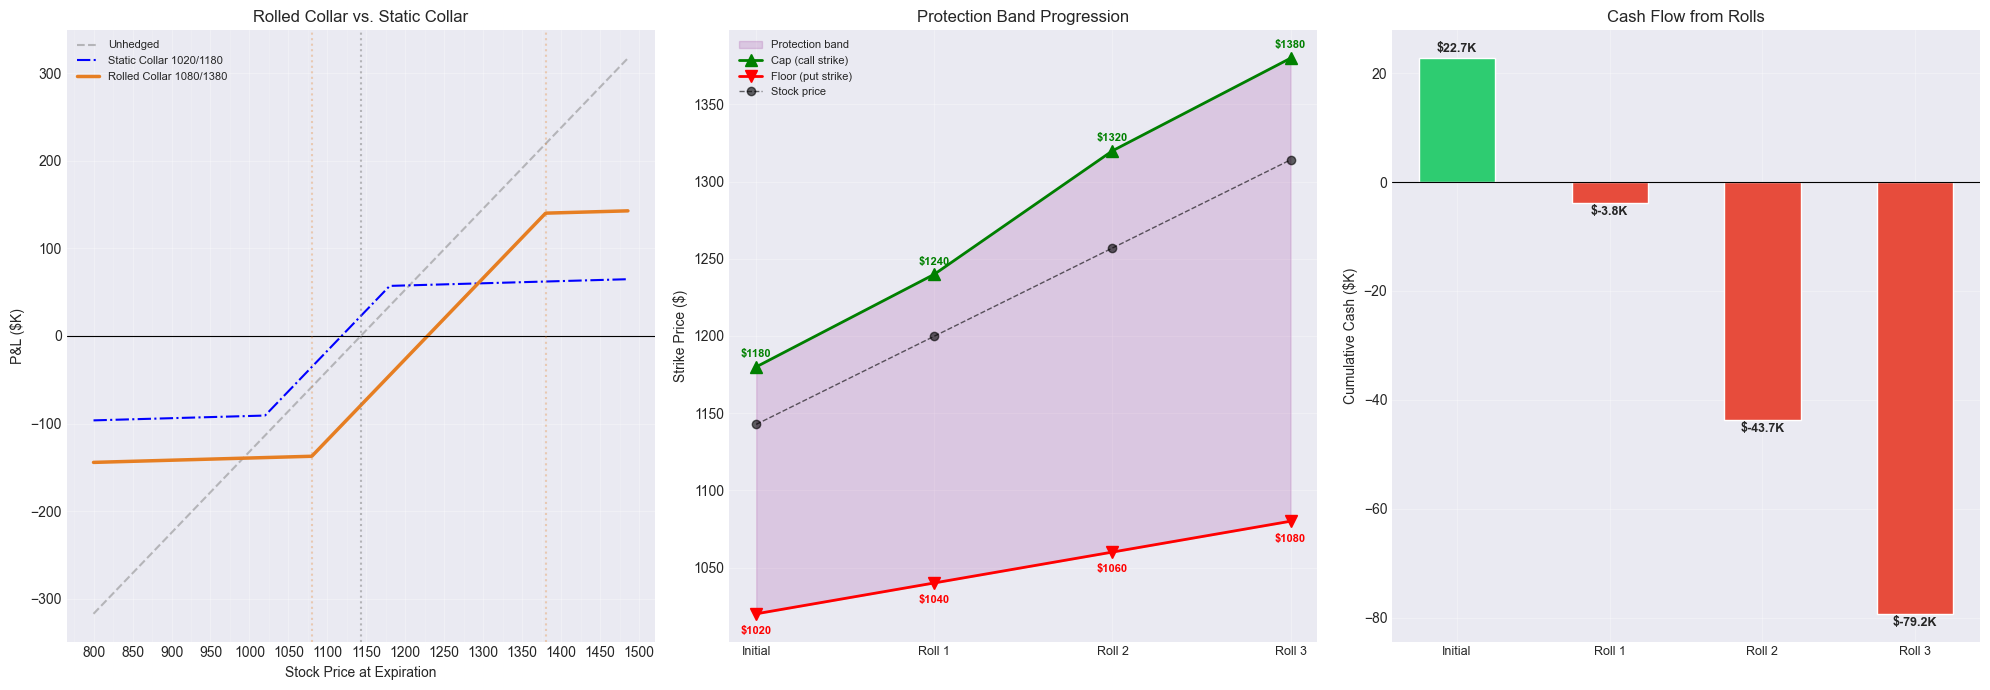


  Terminal P&L -- Rolled Collar vs. Static Collar vs. Unhedged
  Static collar: 1020/1180
  Rolled collar: 1080/1380  |  Cumul. cash: $-79,246.26

Scenario     Price  Unhedged Static Collar Rolled Collar Roll Benefit
    -20%   $914.19 $-211,407      $-93,455     $-141,426     $-47,971
    -15%   $971.33 $-158,555      $-92,026     $-139,998     $-47,971
    -10% $1,028.47 $-105,703      $-82,978     $-138,569     $-55,591
     -5% $1,085.60  $-52,852      $-30,127     $-132,098    $-101,971
    Flat $1,142.74        $0       $22,725      $-79,246    $-101,971
     +5% $1,199.88   $52,852       $57,687      $-26,395     $-84,082
    +10% $1,257.01  $105,703       $59,116       $26,457     $-32,659
    +15% $1,314.15  $158,555       $60,544       $79,309      $18,765
    +20% $1,371.29  $211,407       $61,973      $132,161      $70,188
    +25% $1,428.42  $264,259       $63,401      $141,430      $78,029
    +30% $1,485.56  $317,110       $64,830      $142,858      $78,029

  Roll Bene

In [60]:
# === COLLAR ROLL-UP MODEL (BOTH LEGS) ===
# Starting position from Section 9
collar_initial_put = custom_put_strike
collar_initial_put_prem = custom_put_premium
collar_initial_call = custom_call_strike
collar_initial_call_prem = custom_call_premium

# Time-value estimates for buyback/sellback
call_tv_pct = 0.02    # remaining time value on ITM call as % of stock price
put_tv_pct = 0.01     # remaining time value on OTM put as % of stock price

# --- Roll-up parameters (edit these) ---
roll_trigger_pct = 0.05   # stock rises 5% from current to trigger each roll
call_step_pct = 0.06      # raise call strike by 5% of current_price each roll
put_step_pct = 0.02       # raise put strike by 5% of current_price each roll
num_rolls = 3             # number of roll-up steps

# Auto-generate roll steps from the percentages above
collar_roll_steps = []
for i in range(1, num_rolls + 1):
    roll_price = current_price * (1 + roll_trigger_pct * i)
    new_put = round(collar_initial_put + current_price * put_step_pct * i)
    new_call = round(collar_initial_call + current_price * call_step_pct * i)
    collar_roll_steps.append((roll_price, new_put, new_call))

# Or override manually -- uncomment and edit the list below:
# collar_roll_steps = [
#     (current_price * 1.05, 1200, 1360),
#     (current_price * 1.10, 1260, 1420),
#     (current_price * 1.15, 1320, 1480),
# ]

# =====================================================================
# MODEL EXECUTION -- no edits needed below
# =====================================================================

def lookup_put_premium(strike, puts_df):
    """Look up mid-price for a put strike from the chain (snaps to nearest)."""
    row = puts_df.iloc[(puts_df['strike'] - strike).abs().argsort()[:1]]
    actual_strike = row['strike'].values[0]
    mid = (row['bid'].values[0] + row['ask'].values[0]) / 2
    if mid == 0:
        mid = row['lastPrice'].values[0]
    return actual_strike, mid

def estimate_put_salvage(stock_price, long_put_strike, tv_pct):
    """Estimate proceeds from selling back a long put (now further OTM)."""
    intrinsic = max(long_put_strike - stock_price, 0)
    time_value = stock_price * tv_pct
    return intrinsic + time_value

# --- Process collar rolls ---
print(f"{'='*80}")
print(f"  Collar Roll-Up Model (Both Legs) -- MPWR @ ${current_price:.2f}, exp {selected_exp}")
print(f"{'='*80}")
print(f"  Starting collar: Put ${collar_initial_put:.0f} @ ${collar_initial_put_prem:.2f}"
      f"  |  Call ${collar_initial_call:.0f} @ ${collar_initial_call_prem:.2f}")
collar_init_net = collar_initial_put_prem - collar_initial_call_prem
collar_init_label = 'cost' if collar_init_net > 0 else 'credit'
print(f"  Initial collar net {collar_init_label}: ${abs(collar_init_net):.2f}/share"
      f"  (${abs(collar_init_net * COVERED_SHARES):,.2f} total)")
print(f"  Time-value buffers: call={call_tv_pct:.1%}, put={put_tv_pct:.1%}")
print(f"  Roll trigger: {roll_trigger_pct:.0%} stock rise  |  "
      f"Call step: {call_step_pct:.0%}  |  Put step: {put_step_pct:.0%}")
print()

cur_put_strike = collar_initial_put
cur_call_strike = collar_initial_call
# Cumulative cash: initial call premium received minus initial put premium paid
cumul_cash = (collar_initial_call_prem - collar_initial_put_prem) * COVERED_SHARES
collar_log = []

# Log initial position
collar_log.append({
    'Step': 'Initial',
    'Stock': f'${current_price:.0f}',
    'Put Action': f'Buy {CONTRACTS}P @ ${collar_initial_put:.0f}',
    'Call Action': f'Sell {CONTRACTS}C @ ${collar_initial_call:.0f}',
    'Put Cost': f'${collar_initial_put_prem:.2f}',
    'Put Salvage': '--',
    'Call Buyback': '--',
    'Call Premium': f'${collar_initial_call_prem:.2f}',
    'Roll Net': f'{"+" if cumul_cash >= 0 else ""}${cumul_cash / COVERED_SHARES:.2f}',
    'Cumul ($K)': f'{"+" if cumul_cash >= 0 else ""}${cumul_cash / 1000:.1f}K',
    'Floor': f'${collar_initial_put:.0f}',
    'Cap': f'${collar_initial_call:.0f}',
    '_put': collar_initial_put,
    '_call': collar_initial_call,
    '_stock': current_price,
    '_cumul': cumul_cash,
})

for i, (roll_price, new_put, new_call) in enumerate(collar_roll_steps, 1):
    # --- Call leg ---
    call_buyback = estimate_buyback_cost(roll_price, cur_call_strike, call_tv_pct)
    actual_new_call, new_call_prem = lookup_call_premium(new_call, calls)
    call_net = new_call_prem - call_buyback

    # --- Put leg ---
    put_salvage = estimate_put_salvage(roll_price, cur_put_strike, put_tv_pct)
    actual_new_put, new_put_prem = lookup_put_premium(new_put, puts)
    put_net = put_salvage - new_put_prem  # positive = credit (unlikely), negative = cost

    # Combined roll net
    roll_net_per_share = call_net + put_net
    roll_net_total = roll_net_per_share * COVERED_SHARES
    cumul_cash += roll_net_total

    collar_log.append({
        'Step': f'Roll {i}',
        'Stock': f'${roll_price:.0f}',
        'Put Action': f'Sell {CONTRACTS}P @ ${cur_put_strike:.0f}, Buy {CONTRACTS}P @ ${actual_new_put:.0f}',
        'Call Action': f'Buy {CONTRACTS}C @ ${cur_call_strike:.0f}, Sell {CONTRACTS}C @ ${actual_new_call:.0f}',
        'Put Cost': f'${new_put_prem:.2f}',
        'Put Salvage': f'${put_salvage:.2f}',
        'Call Buyback': f'${call_buyback:.2f}',
        'Call Premium': f'${new_call_prem:.2f}',
        'Roll Net': f'{"+" if roll_net_per_share >= 0 else ""}${roll_net_per_share:.2f}',
        'Cumul ($K)': f'{"+" if cumul_cash >= 0 else ""}${cumul_cash / 1000:.1f}K',
        'Floor': f'${actual_new_put:.0f}',
        'Cap': f'${actual_new_call:.0f}',
        '_put': actual_new_put,
        '_call': actual_new_call,
        '_stock': roll_price,
        '_cumul': cumul_cash,
    })

    cur_put_strike = actual_new_put
    cur_call_strike = actual_new_call

final_put = cur_put_strike
final_call = cur_call_strike

# --- Roll Summary Table ---
print("  Roll-by-Roll Detail:")
print()
summary_cols = ['Step', 'Stock', 'Call Buyback', 'Call Premium', 'Put Salvage', 'Put Cost',
                'Roll Net', 'Cumul ($K)', 'Floor', 'Cap']
collar_roll_df = pd.DataFrame(collar_log)
print(collar_roll_df[summary_cols].to_string(index=False))
print()

# --- Assessment ---
print(f"  {'-'*70}")
print(f"  Floor raised: ${collar_initial_put:.0f} -> ${final_put:.0f}  "
      f"(+${final_put - collar_initial_put:.0f})")
print(f"  Cap raised:   ${collar_initial_call:.0f} -> ${final_call:.0f}  "
      f"(+${final_call - collar_initial_call:.0f})")
if cumul_cash >= 0:
    print(f"  Net cash after all rolls: +${cumul_cash:,.2f}  (self-funding!)")
else:
    print(f"  Net cash after all rolls: -${abs(cumul_cash):,.2f}  (total cost of roll-ups)")
print(f"  {'-'*70}")

# --- Three-Panel Chart ---
from matplotlib.ticker import MultipleLocator

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Panel 1: P&L comparison at expiration
comp_range = np.linspace(current_price * 0.70, current_price * 1.30, 500)

# Static collar (never rolled)
static_collar = pnl_collar(comp_range, current_price,
                            collar_initial_put, collar_initial_put_prem,
                            collar_initial_call, collar_initial_call_prem,
                            COVERED_SHARES, UNCOVERED_SHARES)

# Rolled collar: floor at final_put, cap at final_call, plus cumulative cash
rolled_stock = np.where(
    comp_range < final_put,
    (final_put - current_price) * COVERED_SHARES + (comp_range - current_price) * UNCOVERED_SHARES,
    np.where(
        comp_range > final_call,
        (final_call - current_price) * COVERED_SHARES + (comp_range - current_price) * UNCOVERED_SHARES,
        (comp_range - current_price) * (COVERED_SHARES + UNCOVERED_SHARES)
    )
)
rolled_collar = rolled_stock + cumul_cash

unhedged_comp = pnl_unhedged(comp_range, current_price, SHARES)

ax1 = axes[0]
ax1.plot(comp_range, unhedged_comp / 1000, label='Unhedged', linestyle='--', alpha=0.5, color='gray')
ax1.plot(comp_range, static_collar / 1000, label=f'Static Collar {collar_initial_put:.0f}/{collar_initial_call:.0f}',
         linestyle='-.', linewidth=1.5, color='blue')
ax1.plot(comp_range, rolled_collar / 1000, label=f'Rolled Collar {final_put:.0f}/{final_call:.0f}',
         linewidth=2.5, color='#e67e22')
ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.axvline(x=current_price, color='gray', linestyle=':', alpha=0.5)
ax1.axvline(x=final_put, color='#e67e22', linestyle=':', alpha=0.3)
ax1.axvline(x=final_call, color='#e67e22', linestyle=':', alpha=0.3)
ax1.xaxis.set_major_locator(MultipleLocator(50))
ax1.xaxis.set_minor_locator(MultipleLocator(25))
ax1.set_xlabel('Stock Price at Expiration')
ax1.set_ylabel('P&L ($K)')
ax1.set_title('Rolled Collar vs. Static Collar')
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(True, which='major', alpha=0.3)
ax1.grid(True, which='minor', alpha=0.15)

# Panel 2: Floor & Cap progression
ax2 = axes[1]
steps_x = list(range(len(collar_log)))
floors = [r['_put'] for r in collar_log]
caps = [r['_call'] for r in collar_log]
stock_prices = [r['_stock'] for r in collar_log]
step_labels = [r['Step'] for r in collar_log]

ax2.fill_between(steps_x, floors, caps, alpha=0.15, color='purple', label='Protection band')
ax2.plot(steps_x, caps, 'g^-', markersize=8, linewidth=2, label='Cap (call strike)')
ax2.plot(steps_x, floors, 'rv-', markersize=8, linewidth=2, label='Floor (put strike)')
ax2.plot(steps_x, stock_prices, 'ko--', markersize=6, linewidth=1, alpha=0.6, label='Stock price')

for s, f, c in zip(steps_x, floors, caps):
    ax2.text(s, f - 8, f'${f:.0f}', ha='center', va='top', fontsize=8, color='red', fontweight='bold')
    ax2.text(s, c + 5, f'${c:.0f}', ha='center', va='bottom', fontsize=8, color='green', fontweight='bold')

ax2.set_xticks(steps_x)
ax2.set_xticklabels(step_labels, fontsize=9)
ax2.set_ylabel('Strike Price ($)')
ax2.set_title('Protection Band Progression')
ax2.legend(loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.3)

# Panel 3: Cumulative cash flow
ax3 = axes[2]
cumuls = [r['_cumul'] for r in collar_log]
colors = ['#2ecc71' if c >= 0 else '#e74c3c' for c in cumuls]
bars = ax3.bar(steps_x, [c / 1000 for c in cumuls], color=colors, edgecolor='white', width=0.5)

for s, c in zip(steps_x, cumuls):
    va = 'bottom' if c >= 0 else 'top'
    offset = 0.5 if c >= 0 else -0.5
    ax3.text(s, c / 1000 + offset, f'${c / 1000:.1f}K', ha='center', va=va,
             fontsize=9, fontweight='bold')

ax3.axhline(y=0, color='black', linewidth=0.8)
ax3.set_xticks(steps_x)
ax3.set_xticklabels(step_labels, fontsize=9)
ax3.set_ylabel('Cumulative Cash ($K)')
ax3.set_title('Cash Flow from Rolls')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Terminal scenario table ---
print(f"\n{'='*80}")
print(f"  Terminal P&L -- Rolled Collar vs. Static Collar vs. Unhedged")
print(f"{'='*80}")
print(f"  Static collar: {collar_initial_put:.0f}/{collar_initial_call:.0f}")
print(f"  Rolled collar: {final_put:.0f}/{final_call:.0f}  |  Cumul. cash: ${cumul_cash:,.2f}\n")

t_rows = []
for pct in range(-20, 35, 5):
    label = f'{pct}%' if pct < 0 else ('Flat' if pct == 0 else f'+{pct}%')
    price = current_price * (1 + pct / 100)
    p = np.array([price])
    u = pnl_unhedged(p, current_price, SHARES)[0]
    sc = pnl_collar(p, current_price, collar_initial_put, collar_initial_put_prem,
                    collar_initial_call, collar_initial_call_prem, COVERED_SHARES, UNCOVERED_SHARES)[0]
    # Rolled collar P&L
    if price < final_put:
        r_stock = (final_put - current_price) * COVERED_SHARES + (price - current_price) * UNCOVERED_SHARES
    elif price > final_call:
        r_stock = (final_call - current_price) * COVERED_SHARES + (price - current_price) * UNCOVERED_SHARES
    else:
        r_stock = (price - current_price) * (COVERED_SHARES + UNCOVERED_SHARES)
    rc = r_stock + cumul_cash
    t_rows.append({
        'Scenario': label,
        'Price': f'${price:,.2f}',
        'Unhedged': f'${u:,.0f}',
        'Static Collar': f'${sc:,.0f}',
        'Rolled Collar': f'${rc:,.0f}',
        'Roll Benefit': f'${rc - sc:,.0f}',
    })

t_df = pd.DataFrame(t_rows)
print(t_df.to_string(index=False))
print(f"\n  Roll Benefit = Rolled Collar P&L minus Static Collar P&L")
print(f"{'='*80}")

## 12. Cash-Neutral Collar Roll-Up

Model rolling **both** collar legs upward while keeping each roll's **net cash flow as close to zero as possible**.

**How it works:** At each roll trigger, the call leg is rolled up by a fixed step (same as Section 11).
The put leg is then **auto-determined**: the model searches the options chain for the put strike whose
premium makes the combined roll net ≈ $0.

- **Formula:** `target_put_premium = put_salvage + call_net` (this zeroes out the roll)
- If achievable: both floor and cap are raised with no additional cash outlay
- If NOT achievable (call leg too expensive): the put is **not rolled** that step — the floor stays,
  the cap still rises, and the residual call-leg debit is reported

**Configure:**
- `cn_roll_trigger_pct` — stock price increase (%) that triggers each roll
- `cn_call_step_pct` — how much (% of current price) to raise the **call** strike at each roll
- `cn_num_rolls` — number of roll-up steps to model

The put strike is determined automatically — no `put_step_pct` needed.

  Cash-Neutral Collar Roll-Up -- MPWR @ $1142.74, exp 2026-03-20
  Starting collar: Put $1020 @ $15.75  |  Call $1180 @ $41.00
  Initial collar net credit: $25.25/share  ($22,725.00 total)
  Time-value buffers: call=2.0%, put=1.0%
  Roll trigger: 5% stock rise  |  Call step: 6%  |  Put: CASH-NEUTRAL (auto)

  Roll-by-Roll Detail:

   Step Stock Call Buyback Call Premium Put Salvage Put Cost Roll Net Cumul ($K) Floor   Cap                   Note
Initial $1143           --       $41.00          --   $15.75  +$25.25    +$22.7K $1020 $1180                       
 Roll 1 $1200       $43.87       $21.95          --       --  $-21.92     +$3.0K $1020 $1240 call-only (floor kept)
 Roll 2 $1257       $42.15       $10.45          --       --  $-31.70    $-25.5K $1020 $1320 call-only (floor kept)
 Roll 3 $1314       $26.28        $5.15          --       --  $-21.13    $-44.6K $1020 $1380 call-only (floor kept)

  ----------------------------------------------------------------------
  Floor raise

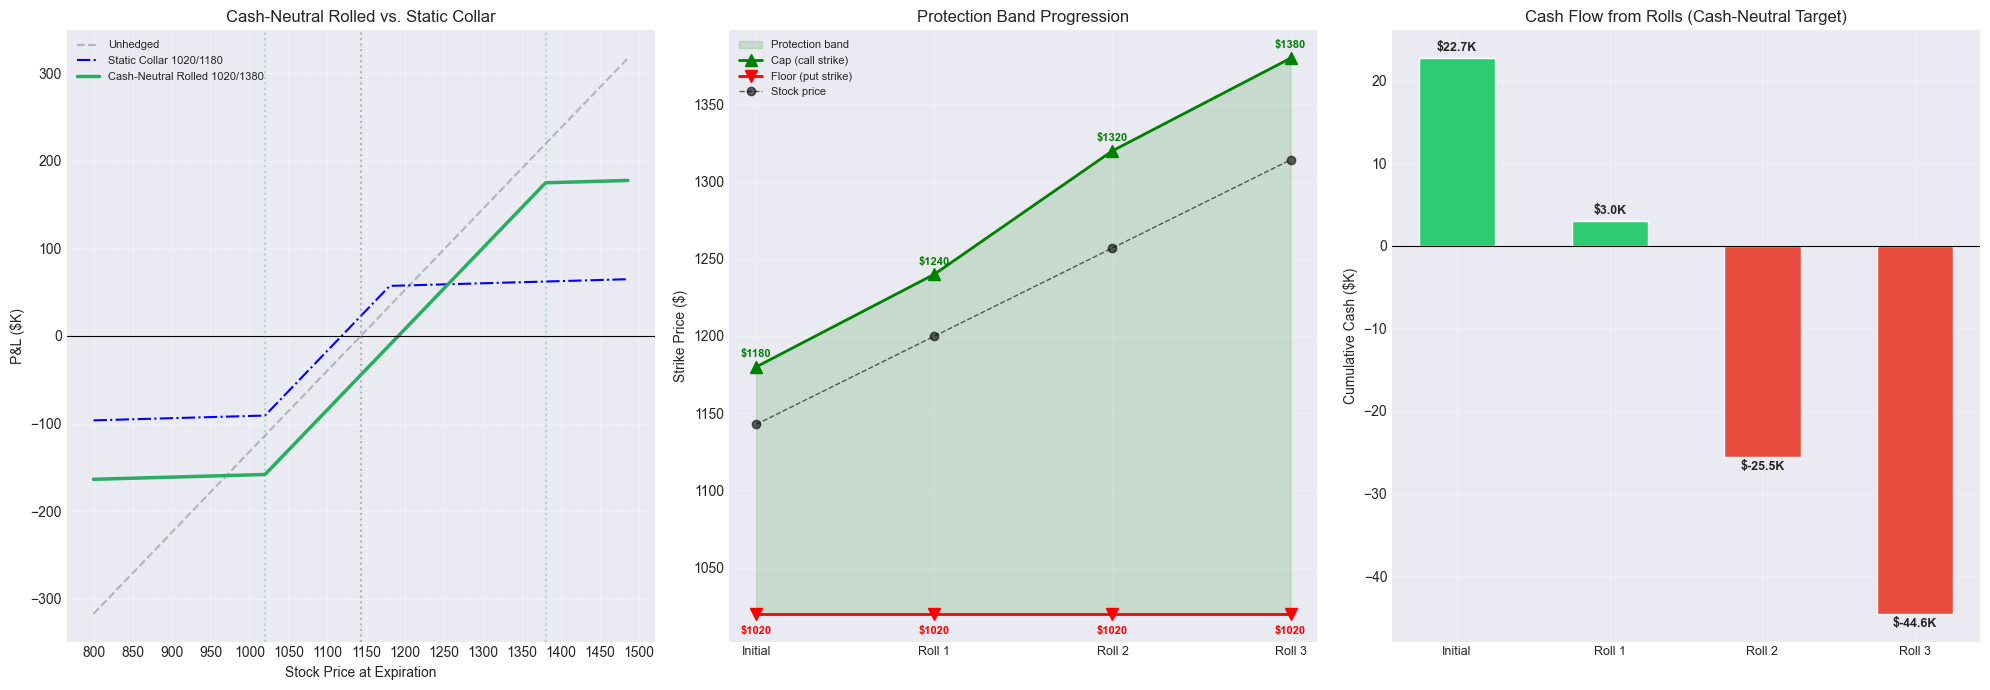


  Terminal P&L -- Cash-Neutral Rolled Collar vs. Static Collar vs. Unhedged
  Static collar: 1020/1180
  Cash-neutral rolled: 1020/1380  |  Cumul. cash: $-44,560.64

Scenario     Price  Unhedged Static Collar CN Rolled Roll Benefit
    -20%   $914.19 $-211,407      $-93,455 $-160,740     $-67,286
    -15%   $971.33 $-158,555      $-92,026 $-159,312     $-67,286
    -10% $1,028.47 $-105,703      $-82,978 $-150,264     $-67,286
     -5% $1,085.60  $-52,852      $-30,127  $-97,412     $-67,286
    Flat $1,142.74        $0       $22,725  $-44,561     $-67,286
     +5% $1,199.88   $52,852       $57,687    $8,291     $-49,396
    +10% $1,257.01  $105,703       $59,116   $61,143       $2,027
    +15% $1,314.15  $158,555       $60,544  $113,995      $53,450
    +20% $1,371.29  $211,407       $61,973  $166,846     $104,874
    +25% $1,428.42  $264,259       $63,401  $176,115     $112,714
    +30% $1,485.56  $317,110       $64,830  $177,544     $112,714

  Roll Benefit = Cash-Neutral Rolled P&L

In [61]:
# === CASH-NEUTRAL COLLAR ROLL-UP MODEL ===
# Starting position from Section 9
cn_initial_put = custom_put_strike
cn_initial_put_prem = custom_put_premium
cn_initial_call = custom_call_strike
cn_initial_call_prem = custom_call_premium

# Time-value estimates for buyback/sellback
cn_call_tv_pct = 0.02    # remaining time value on ITM call as % of stock price
cn_put_tv_pct = 0.01     # remaining time value on OTM put as % of stock price

# --- Roll-up parameters (edit these) ---
cn_roll_trigger_pct = 0.05   # stock rises 5% from current to trigger each roll
cn_call_step_pct = 0.06      # raise call strike by 6% of current_price each roll
cn_num_rolls = 3              # number of roll-up steps

# Auto-generate roll steps: (roll_price, new_call) — put is determined dynamically
cn_roll_steps = []
for _i in range(1, cn_num_rolls + 1):
    _roll_price = current_price * (1 + cn_roll_trigger_pct * _i)
    _new_call = round(cn_initial_call + current_price * cn_call_step_pct * _i)
    cn_roll_steps.append((_roll_price, _new_call))

# =====================================================================
# HELPER: find put strike for a target premium (cash-neutral)
# =====================================================================

def find_put_for_target_premium(target_premium, puts_df, min_strike=None, max_strike=None):
    """Find the put strike whose chain premium best matches target_premium.

    For cash-neutral rolls: we want the put whose cost equals the budget
    available so that the combined roll nets to zero.
    min_strike prevents lowering the floor below the current put.
    max_strike prevents buying ITM puts above the stock price.
    """
    df = puts_df.copy()
    if max_strike is not None:
        df = df[df['strike'] <= max_strike]
    if min_strike is not None:
        df = df[df['strike'] >= min_strike]
    if len(df) == 0:
        return None, None
    df = df.copy()
    df['mid'] = (df['bid'] + df['ask']) / 2
    mask = df['mid'] == 0
    df.loc[mask, 'mid'] = df.loc[mask, 'lastPrice']
    # Find closest premium to target
    df['diff'] = (df['mid'] - target_premium).abs()
    best_idx = df['diff'].idxmin()
    return df.loc[best_idx, 'strike'], df.loc[best_idx, 'mid']

# =====================================================================
# MODEL EXECUTION
# =====================================================================

print(f"{'='*80}")
print(f"  Cash-Neutral Collar Roll-Up -- MPWR @ ${current_price:.2f}, exp {selected_exp}")
print(f"{'='*80}")
print(f"  Starting collar: Put ${cn_initial_put:.0f} @ ${cn_initial_put_prem:.2f}"
      f"  |  Call ${cn_initial_call:.0f} @ ${cn_initial_call_prem:.2f}")
cn_init_net = cn_initial_put_prem - cn_initial_call_prem
cn_init_label = 'cost' if cn_init_net > 0 else 'credit'
print(f"  Initial collar net {cn_init_label}: ${abs(cn_init_net):.2f}/share"
      f"  (${abs(cn_init_net * COVERED_SHARES):,.2f} total)")
print(f"  Time-value buffers: call={cn_call_tv_pct:.1%}, put={cn_put_tv_pct:.1%}")
print(f"  Roll trigger: {cn_roll_trigger_pct:.0%} stock rise  |  "
      f"Call step: {cn_call_step_pct:.0%}  |  Put: CASH-NEUTRAL (auto)")
print()

cn_cur_put = cn_initial_put
cn_cur_call = cn_initial_call
cn_cumul = (cn_initial_call_prem - cn_initial_put_prem) * COVERED_SHARES
cn_log = []

# Log initial position
cn_log.append({
    'Step': 'Initial',
    'Stock': f'${current_price:.0f}',
    'Call Buyback': '--',
    'Call Premium': f'${cn_initial_call_prem:.2f}',
    'Put Salvage': '--',
    'Put Cost': f'${cn_initial_put_prem:.2f}',
    'Roll Net': f'+${cn_cumul / COVERED_SHARES:.2f}',
    'Cumul ($K)': f'+${cn_cumul / 1000:.1f}K',
    'Floor': f'${cn_initial_put:.0f}',
    'Cap': f'${cn_initial_call:.0f}',
    'Note': '',
    '_put': cn_initial_put,
    '_call': cn_initial_call,
    '_stock': current_price,
    '_cumul': cn_cumul,
})

for i, (roll_price, new_call) in enumerate(cn_roll_steps, 1):
    # --- Call leg ---
    call_buyback = estimate_buyback_cost(roll_price, cn_cur_call, cn_call_tv_pct)
    actual_new_call, new_call_prem = lookup_call_premium(new_call, calls)
    call_net = new_call_prem - call_buyback

    # --- Put leg (cash-neutral determination) ---
    put_salvage = estimate_put_salvage(roll_price, cn_cur_put, cn_put_tv_pct)
    budget_for_put = put_salvage + call_net  # target new_put_prem for zero roll net

    note = ''
    put_salvage_used = 0.0
    new_put_prem = 0.0
    actual_new_put = cn_cur_put  # default: keep current floor

    if budget_for_put > 0:
        # Cash-neutral achievable: find put with premium ≈ budget
        found_strike, found_prem = find_put_for_target_premium(
            budget_for_put, puts, min_strike=cn_cur_put, max_strike=roll_price)
        if found_strike is not None:
            actual_new_put = found_strike
            new_put_prem = found_prem
            put_salvage_used = put_salvage
            residual = abs((call_net + put_salvage - new_put_prem) * COVERED_SHARES)
            if residual < 500:
                note = 'cash-neutral'
            else:
                note = f'near-neutral (${residual:,.0f} residual)'
        else:
            # No qualifying puts found; keep current put
            note = 'no puts in range'
    else:
        # Cash-neutral NOT achievable: don't roll the put
        note = 'call-only (floor kept)'

    # Compute actual net for this roll
    if put_salvage_used > 0:
        # Both legs rolled
        put_net = put_salvage_used - new_put_prem
        roll_net_per_share = call_net + put_net
    else:
        # Call-only roll (put not touched)
        roll_net_per_share = call_net

    roll_net_total = roll_net_per_share * COVERED_SHARES
    cn_cumul += roll_net_total

    cn_log.append({
        'Step': f'Roll {i}',
        'Stock': f'${roll_price:.0f}',
        'Call Buyback': f'${call_buyback:.2f}',
        'Call Premium': f'${new_call_prem:.2f}',
        'Put Salvage': f'${put_salvage_used:.2f}' if put_salvage_used > 0 else '--',
        'Put Cost': f'${new_put_prem:.2f}' if new_put_prem > 0 else '--',
        'Roll Net': f'{"+" if roll_net_per_share >= 0 else ""}${roll_net_per_share:.2f}',
        'Cumul ($K)': f'{"+" if cn_cumul >= 0 else ""}${cn_cumul / 1000:.1f}K',
        'Floor': f'${actual_new_put:.0f}',
        'Cap': f'${actual_new_call:.0f}',
        'Note': note,
        '_put': actual_new_put,
        '_call': actual_new_call,
        '_stock': roll_price,
        '_cumul': cn_cumul,
    })

    cn_cur_put = actual_new_put
    cn_cur_call = actual_new_call

cn_final_put = cn_cur_put
cn_final_call = cn_cur_call

# --- Roll Summary Table ---
print("  Roll-by-Roll Detail:")
print()
cn_summary_cols = ['Step', 'Stock', 'Call Buyback', 'Call Premium', 'Put Salvage', 'Put Cost',
                   'Roll Net', 'Cumul ($K)', 'Floor', 'Cap', 'Note']
cn_roll_df = pd.DataFrame(cn_log)
print(cn_roll_df[cn_summary_cols].to_string(index=False))
print()

# --- Assessment ---
print(f"  {'-'*70}")
print(f"  Floor raised: ${cn_initial_put:.0f} -> ${cn_final_put:.0f}  "
      f"(+${cn_final_put - cn_initial_put:.0f})")
print(f"  Cap raised:   ${cn_initial_call:.0f} -> ${cn_final_call:.0f}  "
      f"(+${cn_final_call - cn_initial_call:.0f})")
if cn_cumul >= 0:
    print(f"  Net cash after all rolls: +${cn_cumul:,.2f}  (self-funding!)")
else:
    print(f"  Net cash after all rolls: -${abs(cn_cumul):,.2f}  (total cost of roll-ups)")
cn_neutral_count = sum(1 for r in cn_log[1:] if 'cash-neutral' in r.get('Note', ''))
cn_near_count = sum(1 for r in cn_log[1:] if 'near-neutral' in r.get('Note', ''))
cn_callonly_count = sum(1 for r in cn_log[1:] if 'call-only' in r.get('Note', ''))
print(f"  Rolls: {cn_neutral_count} cash-neutral, {cn_near_count} near-neutral, "
      f"{cn_callonly_count} call-only")
print(f"  {'-'*70}")

# --- Three-Panel Chart ---
from matplotlib.ticker import MultipleLocator

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Panel 1: P&L comparison at expiration
cn_comp_range = np.linspace(current_price * 0.70, current_price * 1.30, 500)

# Static collar (never rolled)
cn_static_collar = pnl_collar(cn_comp_range, current_price,
                              cn_initial_put, cn_initial_put_prem,
                              cn_initial_call, cn_initial_call_prem,
                              COVERED_SHARES, UNCOVERED_SHARES)

# Rolled collar: floor at cn_final_put, cap at cn_final_call, plus cumulative cash
cn_rolled_stock = np.where(
    cn_comp_range < cn_final_put,
    (cn_final_put - current_price) * COVERED_SHARES + (cn_comp_range - current_price) * UNCOVERED_SHARES,
    np.where(
        cn_comp_range > cn_final_call,
        (cn_final_call - current_price) * COVERED_SHARES + (cn_comp_range - current_price) * UNCOVERED_SHARES,
        (cn_comp_range - current_price) * (COVERED_SHARES + UNCOVERED_SHARES)
    )
)
cn_rolled_collar = cn_rolled_stock + cn_cumul

cn_unhedged_comp = pnl_unhedged(cn_comp_range, current_price, SHARES)

ax1 = axes[0]
ax1.plot(cn_comp_range, cn_unhedged_comp / 1000, label='Unhedged', linestyle='--', alpha=0.5, color='gray')
ax1.plot(cn_comp_range, cn_static_collar / 1000,
         label=f'Static Collar {cn_initial_put:.0f}/{cn_initial_call:.0f}',
         linestyle='-.', linewidth=1.5, color='blue')
ax1.plot(cn_comp_range, cn_rolled_collar / 1000,
         label=f'Cash-Neutral Rolled {cn_final_put:.0f}/{cn_final_call:.0f}',
         linewidth=2.5, color='#27ae60')
ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.axvline(x=current_price, color='gray', linestyle=':', alpha=0.5)
ax1.axvline(x=cn_final_put, color='#27ae60', linestyle=':', alpha=0.3)
ax1.axvline(x=cn_final_call, color='#27ae60', linestyle=':', alpha=0.3)
ax1.xaxis.set_major_locator(MultipleLocator(50))
ax1.xaxis.set_minor_locator(MultipleLocator(25))
ax1.set_xlabel('Stock Price at Expiration')
ax1.set_ylabel('P&L ($K)')
ax1.set_title('Cash-Neutral Rolled vs. Static Collar')
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(True, which='major', alpha=0.3)
ax1.grid(True, which='minor', alpha=0.15)

# Panel 2: Floor & Cap progression
ax2 = axes[1]
cn_steps_x = list(range(len(cn_log)))
cn_floors = [r['_put'] for r in cn_log]
cn_caps = [r['_call'] for r in cn_log]
cn_stock_prices = [r['_stock'] for r in cn_log]
cn_step_labels = [r['Step'] for r in cn_log]

ax2.fill_between(cn_steps_x, cn_floors, cn_caps, alpha=0.15, color='green', label='Protection band')
ax2.plot(cn_steps_x, cn_caps, 'g^-', markersize=8, linewidth=2, label='Cap (call strike)')
ax2.plot(cn_steps_x, cn_floors, 'rv-', markersize=8, linewidth=2, label='Floor (put strike)')
ax2.plot(cn_steps_x, cn_stock_prices, 'ko--', markersize=6, linewidth=1, alpha=0.6, label='Stock price')

for s, f, c in zip(cn_steps_x, cn_floors, cn_caps):
    ax2.text(s, f - 8, f'${f:.0f}', ha='center', va='top', fontsize=8, color='red', fontweight='bold')
    ax2.text(s, c + 5, f'${c:.0f}', ha='center', va='bottom', fontsize=8, color='green', fontweight='bold')

ax2.set_xticks(cn_steps_x)
ax2.set_xticklabels(cn_step_labels, fontsize=9)
ax2.set_ylabel('Strike Price ($)')
ax2.set_title('Protection Band Progression')
ax2.legend(loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.3)

# Panel 3: Cumulative cash flow
ax3 = axes[2]
cn_cumuls = [r['_cumul'] for r in cn_log]
cn_colors = ['#2ecc71' if c >= 0 else '#e74c3c' for c in cn_cumuls]
bars = ax3.bar(cn_steps_x, [c / 1000 for c in cn_cumuls], color=cn_colors, edgecolor='white', width=0.5)

for s, c in zip(cn_steps_x, cn_cumuls):
    va = 'bottom' if c >= 0 else 'top'
    offset = 0.5 if c >= 0 else -0.5
    ax3.text(s, c / 1000 + offset, f'${c / 1000:.1f}K', ha='center', va=va,
             fontsize=9, fontweight='bold')

ax3.axhline(y=0, color='black', linewidth=0.8)
ax3.set_xticks(cn_steps_x)
ax3.set_xticklabels(cn_step_labels, fontsize=9)
ax3.set_ylabel('Cumulative Cash ($K)')
ax3.set_title('Cash Flow from Rolls (Cash-Neutral Target)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Terminal scenario table ---
print(f"\n{'='*80}")
print(f"  Terminal P&L -- Cash-Neutral Rolled Collar vs. Static Collar vs. Unhedged")
print(f"{'='*80}")
print(f"  Static collar: {cn_initial_put:.0f}/{cn_initial_call:.0f}")
print(f"  Cash-neutral rolled: {cn_final_put:.0f}/{cn_final_call:.0f}  |  "
      f"Cumul. cash: ${cn_cumul:,.2f}\n")

cn_t_rows = []
for pct in range(-20, 35, 5):
    label = f'{pct}%' if pct < 0 else ('Flat' if pct == 0 else f'+{pct}%')
    price = current_price * (1 + pct / 100)
    p = np.array([price])
    u = pnl_unhedged(p, current_price, SHARES)[0]
    sc = pnl_collar(p, current_price, cn_initial_put, cn_initial_put_prem,
                    cn_initial_call, cn_initial_call_prem, COVERED_SHARES, UNCOVERED_SHARES)[0]
    # Rolled collar P&L
    if price < cn_final_put:
        r_stock = (cn_final_put - current_price) * COVERED_SHARES + (price - current_price) * UNCOVERED_SHARES
    elif price > cn_final_call:
        r_stock = (cn_final_call - current_price) * COVERED_SHARES + (price - current_price) * UNCOVERED_SHARES
    else:
        r_stock = (price - current_price) * (COVERED_SHARES + UNCOVERED_SHARES)
    rc = r_stock + cn_cumul
    cn_t_rows.append({
        'Scenario': label,
        'Price': f'${price:,.2f}',
        'Unhedged': f'${u:,.0f}',
        'Static Collar': f'${sc:,.0f}',
        'CN Rolled': f'${rc:,.0f}',
        'Roll Benefit': f'${rc - sc:,.0f}',
    })

cn_t_df = pd.DataFrame(cn_t_rows)
print(cn_t_df.to_string(index=False))
print(f"\n  Roll Benefit = Cash-Neutral Rolled P&L minus Static Collar P&L")
print(f"{'='*80}")

## 13. Collar Position Monitor

Real-time dashboard for monitoring an **existing** collar position. Enter the strikes and prices you actually traded, and this section will show you:

| Category | Metrics |
|---|---|
| **Position snapshot** | Entry price, current price, stock move since entry, days to expiration |
| **Mark-to-market** | Current bid/ask/mid for each leg, unrealized P&L per leg and combined |
| **Moneyness** | ITM/OTM status, distance to strike in $ and %, intrinsic vs. time value |
| **Implied volatility** | IV for each leg from the chain, IV skew (put IV − call IV) |
| **Time decay** | DTE, estimated daily theta per leg (premium ÷ DTE), weekend-adjusted DTE |
| **Protection band** | Where stock sits within floor/cap, % cushion to each boundary |
| **Roll cost matrix** | Cost to roll each leg up or down to nearby strikes |
| **Scenario table** | P&L if stock moves ±5%, ±10%, ±15%, ±20% from current level |
| **Expiration close-out** | Enter an expected price at expiration → full settlement breakdown |

**Configure** the `mon_*` variables in the first code cell with your actual position details.

**Expiration close-out:** In the second code cell below, enter your expected stock price at expiration in `exp_close_price` to see exactly what happens — which options settle ITM, cash flows in/out, net P&L, and what action is required for each leg.

  COLLAR POSITION MONITOR — MPWR @ $1142.74  |  2026-03-20

  --- Position Snapshot ---
  Entry date:    2025-02-27  |  Entry price: $1140.07
  Current price: $1142.74  |  Move since entry: +2.67 (+0.2%)
  Expiration:    2026-03-20  |  DTE: 21 calendar days (~15 trading days)
  Contracts:     9  |  Covered shares: 900
  Entry collar net credit: $22.99/share ($20,690.73 total)

  --- Moneyness & Market Data ---
  Leg          Strike   Status   Dist ($)   Dist (%)  Intrinsic   Time Val       IV
  ----------------------------------------------------------------------------
  Put        $   1020      OTM $  122.74      10.7% $    0.00 $   15.75   54.3%
  Call       $   1180      OTM $   37.26       3.3% $    0.00 $   41.00   50.8%

  IV skew (put − call): +3.5%  (normal: puts cost more)

  --- Mark-to-Market & Unrealized P&L ---
  Leg           Entry      Bid      Ask      Mid     Last      MtM    P&L/sh    P&L Total     Vol      OI
  -------------------------------------------------------

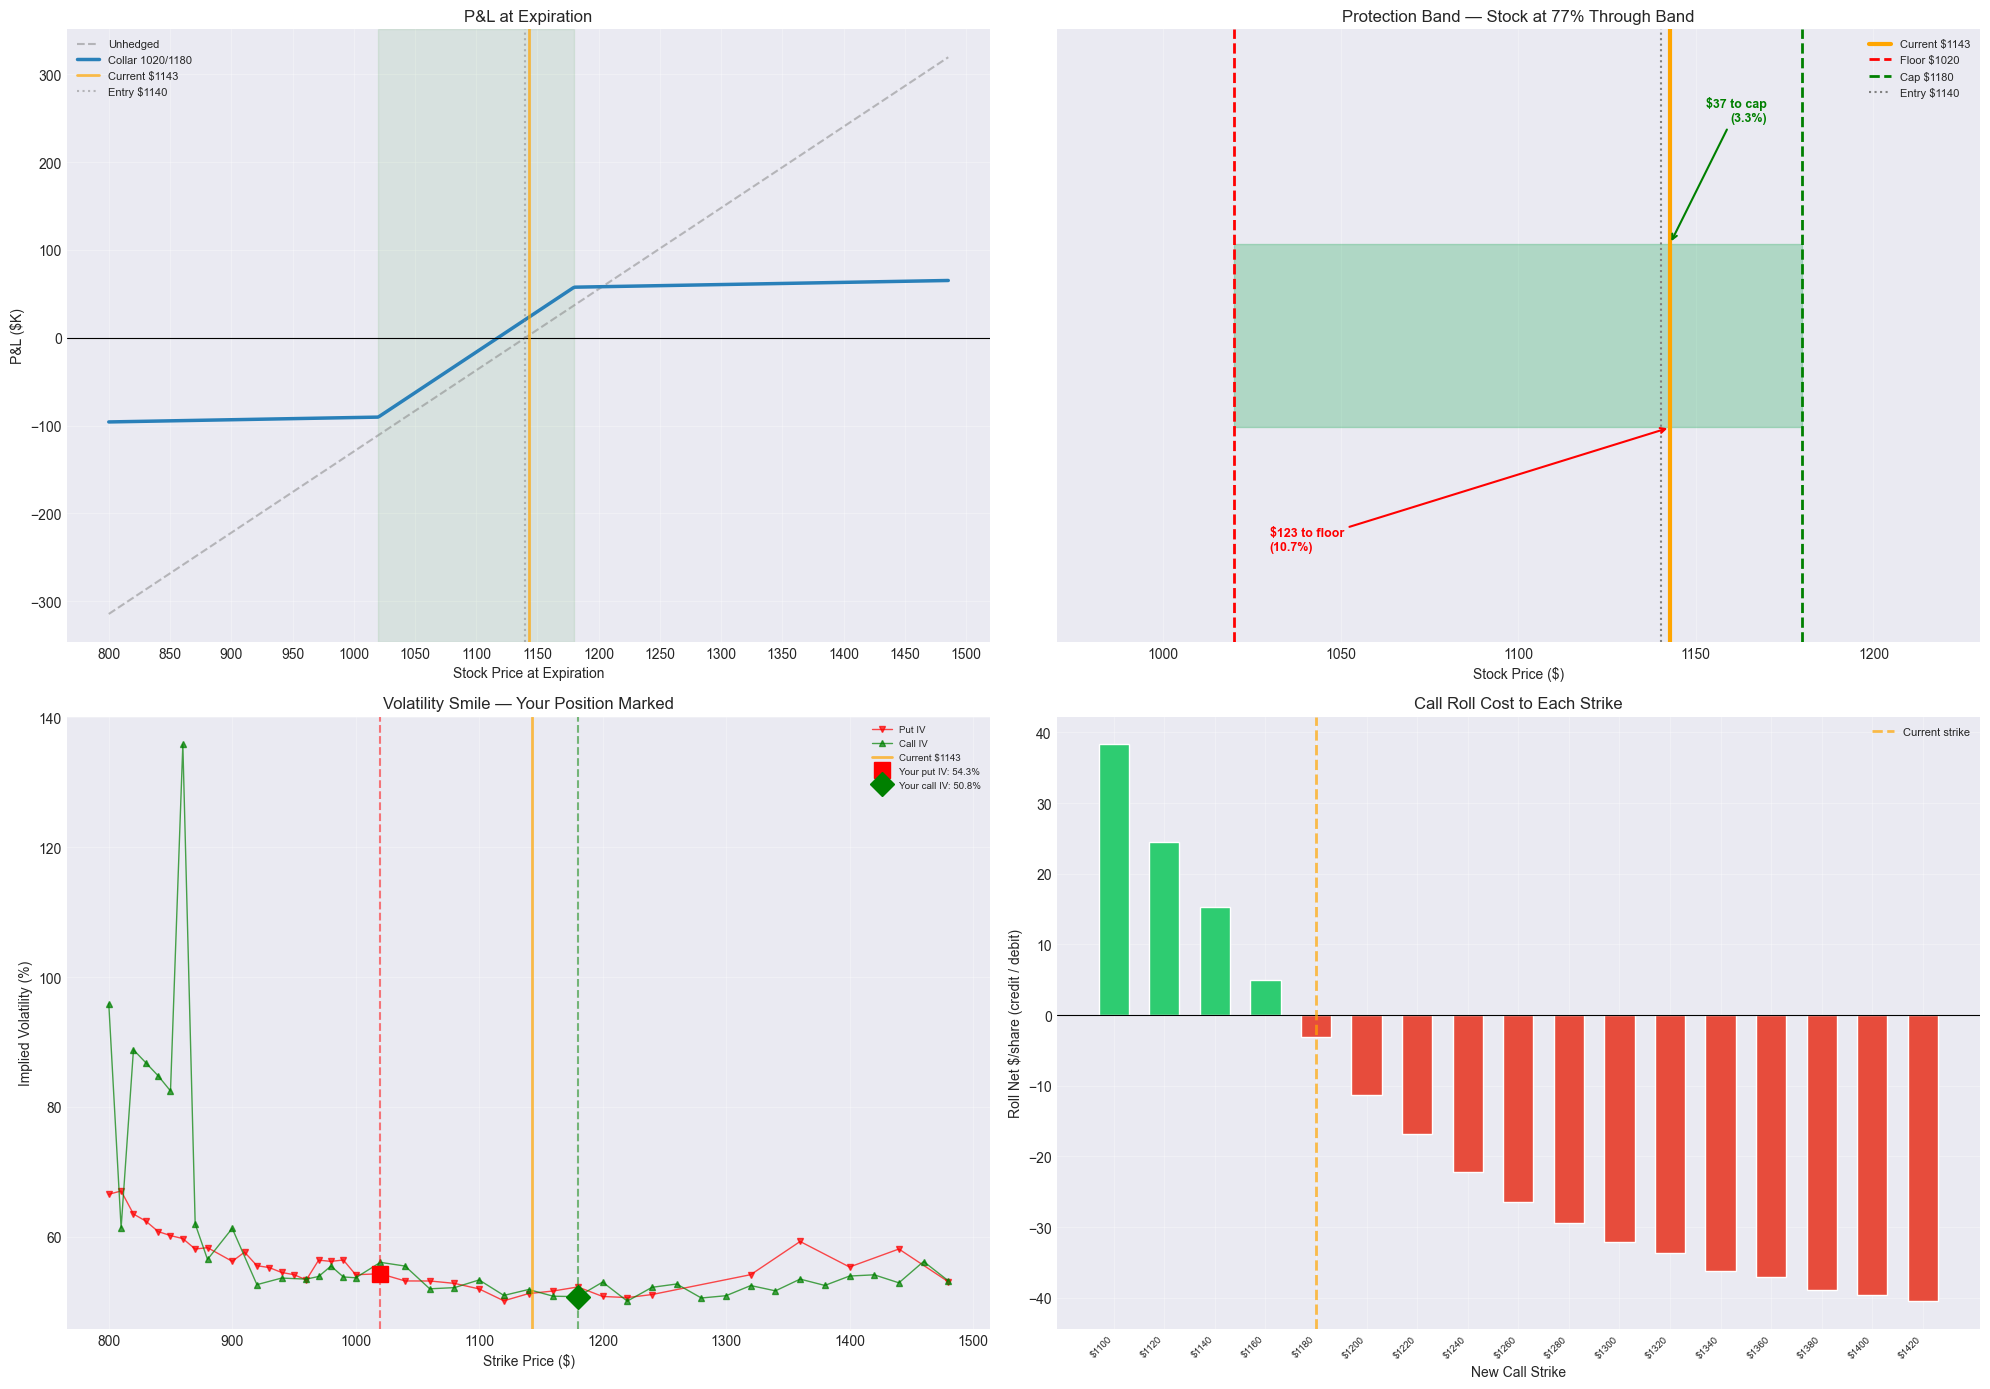


  Position Monitor Complete — run this cell again for updated data


In [62]:
# === COLLAR POSITION MONITOR ===
# Edit these to match your actual traded position
mon_put_strike = 1020        # put strike you bought
mon_call_strike = 1180       # call strike you sold
mon_put_price_paid = 16.4551   # premium you paid per share for the put
mon_call_price_received = 39.4448  # premium you received per share for the call
mon_entry_price = 1140.07    # stock price when you opened the position
mon_entry_date = '2025-02-27'  # date you opened the position (YYYY-MM-DD)

# =====================================================================
# AUTO-LOOKUP CURRENT MARKET DATA FROM CHAIN
# =====================================================================
from datetime import datetime, date

_today = date.today()
_exp_date = datetime.strptime(selected_exp, '%Y-%m-%d').date()
_dte = (_exp_date - _today).days
_trading_dte = _dte * 5 / 7  # rough trading-day estimate

# Snap to nearest available strikes in chain
_p_row = puts.iloc[(puts['strike'] - mon_put_strike).abs().argsort()[:1]]
mon_put_actual = _p_row['strike'].values[0]
mon_put_bid = _p_row['bid'].values[0]
mon_put_ask = _p_row['ask'].values[0]
mon_put_mid = (mon_put_bid + mon_put_ask) / 2
if mon_put_mid == 0:
    mon_put_mid = _p_row['lastPrice'].values[0]
mon_put_last = _p_row['lastPrice'].values[0]
mon_put_iv = _p_row['impliedVolatility'].values[0]
mon_put_vol = _p_row['volume'].values[0]
mon_put_oi = _p_row['openInterest'].values[0]

_c_row = calls.iloc[(calls['strike'] - mon_call_strike).abs().argsort()[:1]]
mon_call_actual = _c_row['strike'].values[0]
mon_call_bid = _c_row['bid'].values[0]
mon_call_ask = _c_row['ask'].values[0]
mon_call_mid = (mon_call_bid + mon_call_ask) / 2
if mon_call_mid == 0:
    mon_call_mid = _c_row['lastPrice'].values[0]
mon_call_last = _c_row['lastPrice'].values[0]
mon_call_iv = _c_row['impliedVolatility'].values[0]
mon_call_vol = _c_row['volume'].values[0]
mon_call_oi = _c_row['openInterest'].values[0]

# =====================================================================
# POSITION SNAPSHOT
# =====================================================================
_stock_move = current_price - mon_entry_price
_stock_move_pct = _stock_move / mon_entry_price * 100
_entry_collar_net = mon_put_price_paid - mon_call_price_received
_entry_collar_label = 'cost' if _entry_collar_net > 0 else 'credit'

print(f"{'='*80}")
print(f"  COLLAR POSITION MONITOR — {TICKER} @ ${current_price:.2f}  |  {selected_exp}")
print(f"{'='*80}")
print()
print(f"  --- Position Snapshot ---")
print(f"  Entry date:    {mon_entry_date}  |  Entry price: ${mon_entry_price:.2f}")
print(f"  Current price: ${current_price:.2f}  |  Move since entry: "
      f"{'+'if _stock_move>=0 else ''}{_stock_move:.2f} ({_stock_move_pct:+.1f}%)")
print(f"  Expiration:    {selected_exp}  |  DTE: {_dte} calendar days (~{_trading_dte:.0f} trading days)")
print(f"  Contracts:     {CONTRACTS}  |  Covered shares: {COVERED_SHARES}")
print(f"  Entry collar net {_entry_collar_label}: ${abs(_entry_collar_net):.2f}/share "
      f"(${abs(_entry_collar_net * COVERED_SHARES):,.2f} total)")
print()

# =====================================================================
# MONEYNESS ANALYSIS
# =====================================================================
_put_intrinsic = max(mon_put_actual - current_price, 0)
_put_time_val = max(mon_put_mid - _put_intrinsic, 0)
_put_itm = current_price < mon_put_actual
_put_dist = current_price - mon_put_actual
_put_dist_pct = _put_dist / current_price * 100

_call_intrinsic = max(current_price - mon_call_actual, 0)
_call_time_val = max(mon_call_mid - _call_intrinsic, 0)
_call_itm = current_price > mon_call_actual
_call_dist = mon_call_actual - current_price
_call_dist_pct = _call_dist / current_price * 100

print(f"  --- Moneyness & Market Data ---")
print(f"  {'Leg':<10} {'Strike':>8} {'Status':>8} {'Dist ($)':>10} {'Dist (%)':>10} "
      f"{'Intrinsic':>10} {'Time Val':>10} {'IV':>8}")
print(f"  {'-'*76}")
print(f"  {'Put':<10} ${mon_put_actual:>7.0f} {'ITM' if _put_itm else 'OTM':>8} "
      f"${abs(_put_dist):>8.2f} {abs(_put_dist_pct):>9.1f}% "
      f"${_put_intrinsic:>8.2f} ${_put_time_val:>8.2f} {mon_put_iv:>7.1%}")
print(f"  {'Call':<10} ${mon_call_actual:>7.0f} {'ITM' if _call_itm else 'OTM':>8} "
      f"${abs(_call_dist):>8.2f} {abs(_call_dist_pct):>9.1f}% "
      f"${_call_intrinsic:>8.2f} ${_call_time_val:>8.2f} {mon_call_iv:>7.1%}")
print()
_iv_skew = mon_put_iv - mon_call_iv
print(f"  IV skew (put − call): {_iv_skew:+.1%}  "
      f"{'(normal: puts cost more)' if _iv_skew > 0 else '(inverted: calls cost more)'}")
print()

# =====================================================================
# CURRENT PRICING & UNREALIZED P&L
# =====================================================================
# Put: you BOUGHT it → current value = what you can sell it for (bid)
# Call: you SOLD it → current cost to close = what you must pay (ask)
_put_mtm = mon_put_bid  # mark-to-market sell price for long put
_call_mtm = mon_call_ask  # mark-to-market buy-to-close price for short call

_put_pnl = (_put_mtm - mon_put_price_paid)  # per share
_call_pnl = (mon_call_price_received - _call_mtm)  # per share (credit entry)
_collar_pnl = _put_pnl + _call_pnl

print(f"  --- Mark-to-Market & Unrealized P&L ---")
print(f"  {'Leg':<10} {'Entry':>8} {'Bid':>8} {'Ask':>8} {'Mid':>8} {'Last':>8} "
      f"{'MtM':>8} {'P&L/sh':>9} {'P&L Total':>12} {'Vol':>7} {'OI':>7}")
print(f"  {'-'*104}")
_pv = mon_put_vol if not (isinstance(mon_put_vol, float) and np.isnan(mon_put_vol)) else 0
_po = mon_put_oi if not (isinstance(mon_put_oi, float) and np.isnan(mon_put_oi)) else 0
_cv = mon_call_vol if not (isinstance(mon_call_vol, float) and np.isnan(mon_call_vol)) else 0
_co = mon_call_oi if not (isinstance(mon_call_oi, float) and np.isnan(mon_call_oi)) else 0
print(f"  {'Put (long)':<10} ${mon_put_price_paid:>6.2f} ${mon_put_bid:>6.2f} "
      f"${mon_put_ask:>6.2f} ${mon_put_mid:>6.2f} ${mon_put_last:>6.2f} "
      f"${_put_mtm:>6.2f} {'+'if _put_pnl>=0 else ''}${_put_pnl:>7.2f} "
      f"{'+'if _put_pnl>=0 else ''}${_put_pnl*COVERED_SHARES:>10,.2f} {int(_pv):>7,} {int(_po):>7,}")
print(f"  {'Call (short)':<10} ${mon_call_price_received:>6.2f} ${mon_call_bid:>6.2f} "
      f"${mon_call_ask:>6.2f} ${mon_call_mid:>6.2f} ${mon_call_last:>6.2f} "
      f"${_call_mtm:>6.2f} {'+'if _call_pnl>=0 else ''}${_call_pnl:>7.2f} "
      f"{'+'if _call_pnl>=0 else ''}${_call_pnl*COVERED_SHARES:>10,.2f} {int(_cv):>7,} {int(_co):>7,}")
print(f"  {'-'*104}")
print(f"  {'Combined':<10} {'':>8} {'':>8} {'':>8} {'':>8} {'':>8} "
      f"{'':>8} {'+'if _collar_pnl>=0 else ''}${_collar_pnl:>7.2f} "
      f"{'+'if _collar_pnl>=0 else ''}${_collar_pnl*COVERED_SHARES:>10,.2f}")
print()

# Stock P&L (on covered shares)
_stock_pnl_covered = _stock_move * COVERED_SHARES
_total_position_pnl = _stock_pnl_covered + _collar_pnl * COVERED_SHARES
print(f"  Stock P&L (covered shares): {'+'if _stock_pnl_covered>=0 else ''}"
      f"${_stock_pnl_covered:,.2f}")
print(f"  Total hedged position P&L:  {'+'if _total_position_pnl>=0 else ''}"
      f"${_total_position_pnl:,.2f}")
print()

# =====================================================================
# TIME DECAY ESTIMATE
# =====================================================================
print(f"  --- Time Decay Estimate ---")
if _dte > 0:
    _put_daily_theta = mon_put_mid / _dte
    _call_daily_theta = mon_call_mid / _dte
    _net_theta = _call_daily_theta - _put_daily_theta  # positive = theta works for you
    print(f"  Put daily theta (est.):  -${_put_daily_theta:.3f}/share  "
          f"(-${_put_daily_theta * COVERED_SHARES:,.2f}/day total)  [costs you]")
    print(f"  Call daily theta (est.): +${_call_daily_theta:.3f}/share  "
          f"(+${_call_daily_theta * COVERED_SHARES:,.2f}/day total)  [benefits you]")
    print(f"  Net daily theta:         {'+'if _net_theta>=0 else ''}${_net_theta:.3f}/share  "
          f"({'+'if _net_theta>=0 else ''}${_net_theta * COVERED_SHARES:,.2f}/day total)")
    if _net_theta > 0:
        print(f"  → Time decay is WORKING FOR you (short call decays faster)")
    else:
        print(f"  → Time decay is WORKING AGAINST you (long put decays faster)")
else:
    print(f"  ⚠ Position has EXPIRED")
print()

# =====================================================================
# PROTECTION BAND STATUS
# =====================================================================
_pct_to_floor = (current_price - mon_put_actual) / current_price * 100
_pct_to_cap = (mon_call_actual - current_price) / current_price * 100
_band_width = mon_call_actual - mon_put_actual
_band_position = (current_price - mon_put_actual) / _band_width * 100 if _band_width > 0 else 0

print(f"  --- Protection Band Status ---")
print(f"  Floor (put):  ${mon_put_actual:.0f}  |  Cushion: ${current_price - mon_put_actual:.2f} ({_pct_to_floor:.1f}% below current)")
print(f"  Cap (call):   ${mon_call_actual:.0f}  |  Room:    ${mon_call_actual - current_price:.2f} ({_pct_to_cap:.1f}% above current)")
print(f"  Band width:   ${_band_width:.0f}  |  Stock at {_band_position:.0f}% through the band")
if current_price < mon_put_actual:
    print(f"  *** BELOW FLOOR — put is ITM, protection is active ***")
elif current_price > mon_call_actual:
    print(f"  *** ABOVE CAP — call is ITM, upside is capped ***")
else:
    print(f"  Stock is within the protection band")
print()

# =====================================================================
# COST TO CLOSE
# =====================================================================
_close_put = mon_put_bid  # sell the long put
_close_call = mon_call_ask  # buy back the short call
_close_net = _close_put - _close_call  # positive = you receive cash
_close_label = 'credit' if _close_net > 0 else 'cost'
print(f"  --- Cost to Close Entire Collar ---")
print(f"  Sell put @ bid ${_close_put:.2f}  |  Buy call @ ask ${_close_call:.2f}")
print(f"  Net {_close_label}: ${abs(_close_net):.2f}/share (${abs(_close_net * COVERED_SHARES):,.2f} total)")
print()

# =====================================================================
# ROLL COST MATRIX — CALL LEG
# =====================================================================
print(f"  --- Roll Cost Matrix: CALL Leg (currently short ${mon_call_actual:.0f} call) ---")
print(f"  Buy back current call @ ask: ${mon_call_ask:.2f}/share")
print()
# Show cost to roll to various higher and lower strikes
_call_targets = calls[
    (calls['strike'] >= current_price * 0.95) &
    (calls['strike'] <= current_price * 1.25)
].copy()
_call_targets = _call_targets.sort_values('strike').reset_index(drop=True)

print(f"  {'New Strike':>12} {'Bid':>8} {'Ask':>8} {'Mid':>8} {'Roll Net/sh':>12} "
      f"{'Roll Net Tot':>13} {'OTM %':>8} {'IV':>8} {'OI':>8}")
print(f"  {'-'*93}")
for _, _r in _call_targets.iterrows():
    _mid = (_r['bid'] + _r['ask']) / 2
    if _mid == 0:
        _mid = _r['lastPrice']
    _roll_net = _mid - mon_call_ask  # sell new at mid, buy back current at ask
    _otm_pct = (_r['strike'] - current_price) / current_price * 100
    _iv = _r['impliedVolatility']
    _oi_val = int(_r['openInterest']) if not (isinstance(_r['openInterest'], float) and np.isnan(_r['openInterest'])) else 0
    _marker = ' <-- current' if _r['strike'] == mon_call_actual else ''
    print(f"  ${_r['strike']:>10.0f} ${_r['bid']:>6.2f} ${_r['ask']:>6.2f} ${_mid:>6.2f} "
          f"{'+'if _roll_net>=0 else ''}${_roll_net:>10.2f} "
          f"{'+'if _roll_net>=0 else ''}${_roll_net*COVERED_SHARES:>11,.2f} "
          f"{_otm_pct:>7.1f}% {_iv:>7.1%} {_oi_val:>8,}{_marker}")
print()

# =====================================================================
# ROLL COST MATRIX — PUT LEG
# =====================================================================
print(f"  --- Roll Cost Matrix: PUT Leg (currently long ${mon_put_actual:.0f} put) ---")
print(f"  Sell back current put @ bid: ${mon_put_bid:.2f}/share")
print()
_put_targets = puts[
    (puts['strike'] >= current_price * 0.75) &
    (puts['strike'] <= current_price * 1.05)
].copy()
_put_targets = _put_targets.sort_values('strike').reset_index(drop=True)

print(f"  {'New Strike':>12} {'Bid':>8} {'Ask':>8} {'Mid':>8} {'Roll Net/sh':>12} "
      f"{'Roll Net Tot':>13} {'OTM %':>8} {'IV':>8} {'OI':>8}")
print(f"  {'-'*93}")
for _, _r in _put_targets.iterrows():
    _mid = (_r['bid'] + _r['ask']) / 2
    if _mid == 0:
        _mid = _r['lastPrice']
    _roll_net = mon_put_bid - _mid  # sell current at bid, buy new at mid
    _otm_pct = (current_price - _r['strike']) / current_price * 100
    _iv = _r['impliedVolatility']
    _oi_val = int(_r['openInterest']) if not (isinstance(_r['openInterest'], float) and np.isnan(_r['openInterest'])) else 0
    _marker = ' <-- current' if _r['strike'] == mon_put_actual else ''
    print(f"  ${_r['strike']:>10.0f} ${_r['bid']:>6.2f} ${_r['ask']:>6.2f} ${_mid:>6.2f} "
          f"{'+'if _roll_net>=0 else ''}${_roll_net:>10.2f} "
          f"{'+'if _roll_net>=0 else ''}${_roll_net*COVERED_SHARES:>11,.2f} "
          f"{_otm_pct:>7.1f}% {_iv:>7.1%} {_oi_val:>8,}{_marker}")
print()

# =====================================================================
# SCENARIO TABLE — P&L from CURRENT LEVEL
# =====================================================================
print(f"{'='*80}")
print(f"  Scenario Analysis — P&L from current level (${current_price:.2f})")
print(f"{'='*80}")
print(f"  Position: Long {CONTRACTS}P @ ${mon_put_actual:.0f}, Short {CONTRACTS}C @ ${mon_call_actual:.0f}")
print(f"  Entry collar net: ${_entry_collar_net:.2f}/share  |  DTE: {_dte}")
print()

_scen_rows = []
for pct in [-20, -15, -10, -5, -3, 0, 3, 5, 10, 15, 20, 25, 30]:
    _label = f'{pct}%' if pct < 0 else ('Flat' if pct == 0 else f'+{pct}%')
    _price = current_price * (1 + pct / 100)

    # Unhedged stock P&L (all shares)
    _u = (_price - mon_entry_price) * SHARES

    # Collar P&L (covered shares)
    _stock_part = (_price - mon_entry_price) * COVERED_SHARES
    if _price < mon_put_actual:
        _put_payoff = (mon_put_actual - _price) * COVERED_SHARES
    else:
        _put_payoff = 0
    if _price > mon_call_actual:
        _call_payoff = -((_price - mon_call_actual) * COVERED_SHARES)
    else:
        _call_payoff = 0
    _collar_cost = _entry_collar_net * COVERED_SHARES
    _hedged_covered = _stock_part + _put_payoff + _call_payoff - _collar_cost

    # Uncovered shares (no hedge)
    _hedged_uncov = (_price - mon_entry_price) * UNCOVERED_SHARES
    _hedged_total = _hedged_covered + _hedged_uncov

    _scen_rows.append({
        'Move': _label,
        'Price': f'${_price:,.2f}',
        'Unhedged': f'${_u:,.0f}',
        'Hedged': f'${_hedged_total:,.0f}',
        'Hedge Benefit': f'${_hedged_total - _u:,.0f}',
    })

_scen_df = pd.DataFrame(_scen_rows)
print(_scen_df.to_string(index=False))
print(f"\n  Hedge Benefit = Hedged P&L minus Unhedged P&L (positive = collar outperforms)")
print()

# =====================================================================
# MAX LOSS / MAX GAIN ANALYSIS
# =====================================================================
# Max loss: stock goes to 0
_max_loss_stock = -mon_entry_price * SHARES
_max_loss_hedged_cov = (-mon_entry_price + mon_put_actual) * COVERED_SHARES + (mon_put_actual - 0) * COVERED_SHARES
_max_loss_hedged = (mon_put_actual - mon_entry_price) * COVERED_SHARES - _entry_collar_net * COVERED_SHARES + (-mon_entry_price) * UNCOVERED_SHARES

# Max gain: stock goes very high (call caps upside on covered shares)
_max_gain_hedged_per_cov = (mon_call_actual - mon_entry_price) - _entry_collar_net
_max_gain_hedged_cov = _max_gain_hedged_per_cov * COVERED_SHARES

print(f"  --- Risk Boundaries (covered shares only) ---")
print(f"  Max loss (stock → ${mon_put_actual:.0f} floor): "
      f"${((mon_put_actual - mon_entry_price) - _entry_collar_net) * COVERED_SHARES:,.2f}")
print(f"  Max gain (stock → ${mon_call_actual:.0f} cap):   "
      f"${_max_gain_hedged_cov:,.2f}")
print(f"  Breakeven: stock at ${mon_entry_price + _entry_collar_net:.2f} "
      f"(entry + collar net)")
print()

# =====================================================================
# VISUAL DASHBOARD — 4-PANEL CHART
# =====================================================================
from matplotlib.ticker import MultipleLocator
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# --- Panel 1: P&L at Expiration ---
ax1 = axes[0, 0]
_px = np.linspace(current_price * 0.70, current_price * 1.30, 500)

_collar_pnl_curve = pnl_collar(
    _px, mon_entry_price,
    mon_put_actual, mon_put_price_paid,
    mon_call_actual, mon_call_price_received,
    COVERED_SHARES, UNCOVERED_SHARES)
_unhedged_curve = pnl_unhedged(_px, mon_entry_price, SHARES)

ax1.plot(_px, _unhedged_curve / 1000, label='Unhedged', linestyle='--', alpha=0.5, color='gray')
ax1.plot(_px, _collar_pnl_curve / 1000, label=f'Collar {mon_put_actual:.0f}/{mon_call_actual:.0f}',
         linewidth=2.5, color='#2980b9')
ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.axvline(x=current_price, color='orange', linestyle='-', alpha=0.7, linewidth=2, label=f'Current ${current_price:.0f}')
ax1.axvline(x=mon_entry_price, color='gray', linestyle=':', alpha=0.5, label=f'Entry ${mon_entry_price:.0f}')
ax1.axvspan(mon_put_actual, mon_call_actual, alpha=0.08, color='green')
ax1.xaxis.set_major_locator(MultipleLocator(50))
ax1.set_xlabel('Stock Price at Expiration')
ax1.set_ylabel('P&L ($K)')
ax1.set_title('P&L at Expiration')
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)

# --- Panel 2: Protection Band Gauge ---
ax2 = axes[0, 1]
ax2.set_xlim(mon_put_actual - 50, mon_call_actual + 50)
ax2.set_ylim(0, 1)
ax2.barh(0.5, _band_width, left=mon_put_actual, height=0.3, color='#27ae60', alpha=0.3, edgecolor='#27ae60')
ax2.axvline(x=current_price, color='orange', linewidth=3, label=f'Current ${current_price:.0f}')
ax2.axvline(x=mon_put_actual, color='red', linewidth=2, linestyle='--', label=f'Floor ${mon_put_actual:.0f}')
ax2.axvline(x=mon_call_actual, color='green', linewidth=2, linestyle='--', label=f'Cap ${mon_call_actual:.0f}')
ax2.axvline(x=mon_entry_price, color='gray', linewidth=1.5, linestyle=':', label=f'Entry ${mon_entry_price:.0f}')
ax2.set_yticks([])
ax2.set_xlabel('Stock Price ($)')
ax2.set_title(f'Protection Band — Stock at {_band_position:.0f}% Through Band')
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, axis='x', alpha=0.3)

# Annotate distances
ax2.annotate(f'${current_price - mon_put_actual:.0f} to floor\n({_pct_to_floor:.1f}%)',
             xy=(current_price, 0.35), xytext=(mon_put_actual + 10, 0.15),
             fontsize=9, color='red', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
ax2.annotate(f'${mon_call_actual - current_price:.0f} to cap\n({_pct_to_cap:.1f}%)',
             xy=(current_price, 0.65), xytext=(mon_call_actual - 10, 0.85),
             fontsize=9, color='green', fontweight='bold', ha='right',
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5))

# --- Panel 3: Implied Volatility Smile ---
ax3 = axes[1, 0]
_all_puts_iv = puts[['strike', 'impliedVolatility']].copy()
_all_calls_iv = calls[['strike', 'impliedVolatility']].copy()
ax3.plot(_all_puts_iv['strike'], _all_puts_iv['impliedVolatility'] * 100,
         'rv-', markersize=4, linewidth=1, alpha=0.7, label='Put IV')
ax3.plot(_all_calls_iv['strike'], _all_calls_iv['impliedVolatility'] * 100,
         'g^-', markersize=4, linewidth=1, alpha=0.7, label='Call IV')
ax3.axvline(x=current_price, color='orange', linewidth=2, alpha=0.7, label=f'Current ${current_price:.0f}')
ax3.axvline(x=mon_put_actual, color='red', linestyle='--', alpha=0.5)
ax3.axvline(x=mon_call_actual, color='green', linestyle='--', alpha=0.5)
ax3.plot(mon_put_actual, mon_put_iv * 100, 'rs', markersize=12, label=f'Your put IV: {mon_put_iv:.1%}')
ax3.plot(mon_call_actual, mon_call_iv * 100, 'gD', markersize=12, label=f'Your call IV: {mon_call_iv:.1%}')
ax3.set_xlabel('Strike Price ($)')
ax3.set_ylabel('Implied Volatility (%)')
ax3.set_title('Volatility Smile — Your Position Marked')
ax3.legend(loc='upper right', fontsize=7)
ax3.grid(True, alpha=0.3)

# --- Panel 4: Roll Cost Waterfall (combined collar roll to next strikes up) ---
ax4 = axes[1, 1]
# Show net cost to roll to each available call strike (from current)
_roll_data = []
for _, _r in _call_targets.iterrows():
    _mid = (_r['bid'] + _r['ask']) / 2
    if _mid == 0:
        _mid = _r['lastPrice']
    _roll_net_val = _mid - mon_call_ask
    _roll_data.append({
        'strike': _r['strike'],
        'roll_net': _roll_net_val,
    })

_rd = pd.DataFrame(_roll_data)
_colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in _rd['roll_net']]
ax4.bar(range(len(_rd)), _rd['roll_net'], color=_colors, edgecolor='white', width=0.6)
ax4.set_xticks(range(len(_rd)))
ax4.set_xticklabels([f'${s:.0f}' for s in _rd['strike']], rotation=45, ha='right', fontsize=7)
ax4.axhline(y=0, color='black', linewidth=0.8)
# Highlight current strike
_cur_idx = None
for _idx, _s in enumerate(_rd['strike']):
    if _s == mon_call_actual:
        _cur_idx = _idx
        break
if _cur_idx is not None:
    ax4.axvline(x=_cur_idx, color='orange', linewidth=2, linestyle='--', alpha=0.7, label='Current strike')
ax4.set_xlabel('New Call Strike')
ax4.set_ylabel('Roll Net $/share (credit / debit)')
ax4.set_title('Call Roll Cost to Each Strike')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print(f"  Position Monitor Complete — run this cell again for updated data")
print(f"{'='*80}")

In [ ]:
# === EXPIRATION CLOSE-OUT SCENARIOS ===
# Enter your expected stock price at/near expiration.
exp_close_price = 1200.00  # <-- CHANGE THIS to your expected price at expiration

# Time-value buffer for pre-expiration estimates (% of stock price)
# Options still have some time value before expiration day.
# Increase these if there are many days left; decrease near expiration.
pre_exp_call_tv_pct = 0.02  # estimated remaining time value on call
pre_exp_put_tv_pct = 0.01   # estimated remaining time value on put

# =====================================================================
# SCENARIO A: CLOSE OUT BEFORE EXPIRATION (keep all shares)
# =====================================================================
# You proactively unwind the collar by:
#   - Buying back the short call (intrinsic + time value)
#   - Selling the long put (intrinsic + time value)
# Result: No assignment, you keep ALL shares.

print(f"{'='*80}")
print(f"  SCENARIO A: EARLY CLOSE-OUT (before expiration — keep all shares)")
print(f"  {TICKER} at ${exp_close_price:.2f}  |  Expiration: {selected_exp}  |  DTE: {_dte}")
print(f"{'='*80}")
print()
print(f"  Position: {CONTRACTS} contracts ({COVERED_SHARES} covered, {UNCOVERED_SHARES} uncovered)")
print(f"  Entry:    ${mon_entry_price:.2f} on {mon_entry_date}")
print(f"  Collar:   Long {mon_put_actual:.0f} put @ ${mon_put_price_paid:.2f}  |  "
      f"Short {mon_call_actual:.0f} call @ ${mon_call_price_received:.2f}")
print()

# --- Estimate option prices at exp_close_price with remaining time value ---
# Call: you are SHORT → you must BUY BACK at intrinsic + time value
_pre_call_intrinsic = max(exp_close_price - mon_call_actual, 0)
_pre_call_tv = exp_close_price * pre_exp_call_tv_pct
_pre_call_buyback = _pre_call_intrinsic + _pre_call_tv
_pre_call_pnl_per = mon_call_price_received - _pre_call_buyback

# Put: you are LONG → you SELL BACK at intrinsic + time value
_pre_put_intrinsic = max(mon_put_actual - exp_close_price, 0)
_pre_put_tv = exp_close_price * pre_exp_put_tv_pct
_pre_put_sellback = _pre_put_intrinsic + _pre_put_tv
_pre_put_pnl_per = _pre_put_sellback - mon_put_price_paid

# Combined option P&L
_pre_collar_pnl_per = _pre_call_pnl_per + _pre_put_pnl_per
_pre_collar_pnl_tot = _pre_collar_pnl_per * COVERED_SHARES

# Stock P&L (you KEEP all shares)
_pre_stock_move = exp_close_price - mon_entry_price
_pre_stock_pnl_all = _pre_stock_move * SHARES

# Total position P&L
_pre_total_pnl = _pre_stock_pnl_all + _pre_collar_pnl_tot

print(f"  --- Call Leg (Short {mon_call_actual:.0f} Call) ---")
if _pre_call_intrinsic > 0:
    print(f"  Call is ITM by ${_pre_call_intrinsic:.2f}  →  buy back to AVOID ASSIGNMENT")
else:
    print(f"  Call is OTM  →  buy back to close (or let expire if near $0)")
print(f"  Est. buyback cost: ${_pre_call_buyback:.2f}/share  "
      f"(intrinsic ${_pre_call_intrinsic:.2f} + time value ${_pre_call_tv:.2f})")
print(f"  You received:      ${mon_call_price_received:.2f}/share at entry")
print(f"  Call leg P&L:      {'+'if _pre_call_pnl_per>=0 else ''}${_pre_call_pnl_per:.2f}/share  "
      f"({'+'if _pre_call_pnl_per*COVERED_SHARES>=0 else ''}${_pre_call_pnl_per*COVERED_SHARES:,.2f} total)")
print()

print(f"  --- Put Leg (Long {mon_put_actual:.0f} Put) ---")
if _pre_put_intrinsic > 0:
    print(f"  Put is ITM by ${_pre_put_intrinsic:.2f}  →  sell back for intrinsic + time value")
else:
    print(f"  Put is OTM  →  sell back for remaining time value only")
print(f"  Est. sell price:   ${_pre_put_sellback:.2f}/share  "
      f"(intrinsic ${_pre_put_intrinsic:.2f} + time value ${_pre_put_tv:.2f})")
print(f"  You paid:          ${mon_put_price_paid:.2f}/share at entry")
print(f"  Put leg P&L:       {'+'if _pre_put_pnl_per>=0 else ''}${_pre_put_pnl_per:.2f}/share  "
      f"({'+'if _pre_put_pnl_per*COVERED_SHARES>=0 else ''}${_pre_put_pnl_per*COVERED_SHARES:,.2f} total)")
print()

# Cash flow to close
_pre_cash_out = _pre_call_buyback * COVERED_SHARES  # buy back call
_pre_cash_in = _pre_put_sellback * COVERED_SHARES    # sell put
_pre_close_net = _pre_cash_in - _pre_cash_out
_pre_close_label = 'credit (you receive)' if _pre_close_net >= 0 else 'cost (you pay)'

print(f"  --- Close-Out Cash Flow ---")
print(f"  Buy back call:     -${_pre_cash_out:,.2f}")
print(f"  Sell put:          +${_pre_cash_in:,.2f}")
print(f"  Net close-out {_pre_close_label}: ${abs(_pre_close_net):,.2f}")
print()

print(f"  --- Total Position After Early Close-Out ---")
print(f"  {'Component':<35} {'Per Share':>12} {'Total':>15}")
print(f"  {'-'*62}")
print(f"  {'Stock P&L (all shares kept)':<35} "
      f"{'+'if _pre_stock_move>=0 else ''}${_pre_stock_move:>10.2f} "
      f"{'+'if _pre_stock_pnl_all>=0 else ''}${_pre_stock_pnl_all:>13,.2f}")
print(f"  {'Call leg P&L (covered)':<35} "
      f"{'+'if _pre_call_pnl_per>=0 else ''}${_pre_call_pnl_per:>10.2f} "
      f"{'+'if _pre_call_pnl_per*COVERED_SHARES>=0 else ''}${_pre_call_pnl_per*COVERED_SHARES:>13,.2f}")
print(f"  {'Put leg P&L (covered)':<35} "
      f"{'+'if _pre_put_pnl_per>=0 else ''}${_pre_put_pnl_per:>10.2f} "
      f"{'+'if _pre_put_pnl_per*COVERED_SHARES>=0 else ''}${_pre_put_pnl_per*COVERED_SHARES:>13,.2f}")
print(f"  {'='*62}")
print(f"  {'TOTAL P&L':<35} {'':>12} "
      f"{'+'if _pre_total_pnl>=0 else ''}${_pre_total_pnl:>13,.2f}")
print()
print(f"  Result: You keep ALL {SHARES} shares worth ${exp_close_price * SHARES:,.2f}")
print(f"  Position value after close: ${exp_close_price * SHARES + _pre_collar_pnl_tot:,.2f} "
      f"(shares + option P&L)")
print()

# =====================================================================
# SCENARIO B: HOLD TO EXPIRATION (assignment/exercise)
# =====================================================================
print(f"{'='*80}")
print(f"  SCENARIO B: HOLD TO EXPIRATION (options settle at intrinsic only)")
print(f"  {TICKER} closing at ${exp_close_price:.2f} on {selected_exp}")
print(f"{'='*80}")
print()
print(f"  Position: {CONTRACTS} contracts ({COVERED_SHARES} shares covered, "
      f"{UNCOVERED_SHARES} uncovered)")
print(f"  Entry:    ${mon_entry_price:.2f} on {mon_entry_date}")
print(f"  Collar:   Long {mon_put_actual:.0f} put @ ${mon_put_price_paid:.2f}  |  "
      f"Short {mon_call_actual:.0f} call @ ${mon_call_price_received:.2f}")
print()

# --- Put leg settlement ---
_exp_put_intrinsic = max(mon_put_actual - exp_close_price, 0)
_exp_put_itm = _exp_put_intrinsic > 0
_exp_put_pnl_per = _exp_put_intrinsic - mon_put_price_paid
_exp_put_pnl_tot = _exp_put_pnl_per * COVERED_SHARES

if _exp_put_itm:
    _put_action = f"PUT is ITM — exercise or sell for ${_exp_put_intrinsic:.2f} intrinsic"
    _put_detail = (f"  You paid ${mon_put_price_paid:.2f} → worth ${_exp_put_intrinsic:.2f} "
                   f"→ net {'profit' if _exp_put_pnl_per >= 0 else 'loss'}: "
                   f"${abs(_exp_put_pnl_per):.2f}/share")
else:
    _put_action = "PUT expires WORTHLESS (OTM)"
    _put_detail = f"  You paid ${mon_put_price_paid:.2f} → total loss: ${mon_put_price_paid:.2f}/share"
    _exp_put_pnl_per = -mon_put_price_paid
    _exp_put_pnl_tot = _exp_put_pnl_per * COVERED_SHARES

print(f"  --- Put Leg (Long {mon_put_actual:.0f} Put) ---")
print(f"  {_put_action}")
print(f"  {_put_detail}")
print(f"  Put P&L: {'+'if _exp_put_pnl_per>=0 else ''}${_exp_put_pnl_per:.2f}/share  "
      f"({'+'if _exp_put_pnl_tot>=0 else ''}${_exp_put_pnl_tot:,.2f} total)")
print()

# --- Call leg settlement ---
_exp_call_intrinsic = max(exp_close_price - mon_call_actual, 0)
_exp_call_itm = _exp_call_intrinsic > 0
_exp_call_pnl_per = mon_call_price_received - _exp_call_intrinsic
_exp_call_pnl_tot = _exp_call_pnl_per * COVERED_SHARES

if _exp_call_itm:
    _call_action = (f"CALL is ITM — expect ASSIGNMENT. Shares called away at "
                    f"${mon_call_actual:.0f}")
    _call_detail = (f"  You received ${mon_call_price_received:.2f} premium → owe "
                    f"${_exp_call_intrinsic:.2f} intrinsic → net "
                    f"{'profit' if _exp_call_pnl_per >= 0 else 'loss'}: "
                    f"${abs(_exp_call_pnl_per):.2f}/share")
else:
    _call_action = "CALL expires WORTHLESS (OTM) — you keep the full premium"
    _call_detail = (f"  You received ${mon_call_price_received:.2f} → full profit: "
                    f"${mon_call_price_received:.2f}/share")
    _exp_call_pnl_per = mon_call_price_received
    _exp_call_pnl_tot = _exp_call_pnl_per * COVERED_SHARES

print(f"  --- Call Leg (Short {mon_call_actual:.0f} Call) ---")
print(f"  {_call_action}")
print(f"  {_call_detail}")
print(f"  Call P&L: {'+'if _exp_call_pnl_per>=0 else ''}${_exp_call_pnl_per:.2f}/share  "
      f"({'+'if _exp_call_pnl_tot>=0 else ''}${_exp_call_pnl_tot:,.2f} total)")
print()

# --- Stock position ---
_exp_stock_move = exp_close_price - mon_entry_price
_exp_stock_move_pct = _exp_stock_move / mon_entry_price * 100

if _exp_call_itm:
    _exp_stock_pnl_covered = (mon_call_actual - mon_entry_price) * COVERED_SHARES
    _shares_status = f"Shares called away at ${mon_call_actual:.0f} (you lose {COVERED_SHARES} covered shares)"
elif _exp_put_itm:
    _exp_stock_pnl_covered = (mon_put_actual - mon_entry_price) * COVERED_SHARES
    _shares_status = f"Put exercisable — can sell shares at ${mon_put_actual:.0f} floor"
else:
    _exp_stock_pnl_covered = (exp_close_price - mon_entry_price) * COVERED_SHARES
    _shares_status = f"Both options expire worthless — you keep shares at ${exp_close_price:.2f}"

_exp_stock_pnl_uncovered = (exp_close_price - mon_entry_price) * UNCOVERED_SHARES

print(f"  --- Stock Position ---")
print(f"  Stock move: ${mon_entry_price:.2f} → ${exp_close_price:.2f}  "
      f"({'+'if _exp_stock_move>=0 else ''}${_exp_stock_move:.2f}, {_exp_stock_move_pct:+.1f}%)")
print(f"  {_shares_status}")
print(f"  Covered shares P&L:   {'+'if _exp_stock_pnl_covered>=0 else ''}"
      f"${_exp_stock_pnl_covered:,.2f}  ({COVERED_SHARES} shares)")
print(f"  Uncovered shares P&L: {'+'if _exp_stock_pnl_uncovered>=0 else ''}"
      f"${_exp_stock_pnl_uncovered:,.2f}  ({UNCOVERED_SHARES} shares)")
print()

# --- Total P&L ---
_exp_options_pnl = _exp_put_pnl_tot + _exp_call_pnl_tot
_exp_total_covered = _exp_stock_pnl_covered + _exp_options_pnl
_exp_total_all = _exp_total_covered + _exp_stock_pnl_uncovered
_exp_unhedged = _exp_stock_move * SHARES

print(f"  {'='*70}")
print(f"  TOTAL P&L SUMMARY")
print(f"  {'='*70}")
print(f"  {'Component':<35} {'Per Share':>12} {'Total':>15}")
print(f"  {'-'*62}")
print(f"  {'Stock (covered shares)':<35} "
      f"{'+'if _exp_stock_pnl_covered/COVERED_SHARES>=0 else ''}${_exp_stock_pnl_covered/COVERED_SHARES:>10.2f} "
      f"{'+'if _exp_stock_pnl_covered>=0 else ''}${_exp_stock_pnl_covered:>13,.2f}")
print(f"  {'Put leg':<35} "
      f"{'+'if _exp_put_pnl_per>=0 else ''}${_exp_put_pnl_per:>10.2f} "
      f"{'+'if _exp_put_pnl_tot>=0 else ''}${_exp_put_pnl_tot:>13,.2f}")
print(f"  {'Call leg':<35} "
      f"{'+'if _exp_call_pnl_per>=0 else ''}${_exp_call_pnl_per:>10.2f} "
      f"{'+'if _exp_call_pnl_tot>=0 else ''}${_exp_call_pnl_tot:>13,.2f}")
print(f"  {'-'*62}")
print(f"  {'Hedged P&L (covered)':<35} "
      f"{'+'if _exp_total_covered/COVERED_SHARES>=0 else ''}${_exp_total_covered/COVERED_SHARES:>10.2f} "
      f"{'+'if _exp_total_covered>=0 else ''}${_exp_total_covered:>13,.2f}")
print(f"  {'Uncovered shares P&L':<35} "
      f"{'+'if _exp_stock_pnl_uncovered/max(UNCOVERED_SHARES,1)>=0 else ''}${_exp_stock_pnl_uncovered/max(UNCOVERED_SHARES,1):>10.2f} "
      f"{'+'if _exp_stock_pnl_uncovered>=0 else ''}${_exp_stock_pnl_uncovered:>13,.2f}")
print(f"  {'='*62}")
print(f"  {'TOTAL POSITION P&L':<35} "
      f"{'':>12} "
      f"{'+'if _exp_total_all>=0 else ''}${_exp_total_all:>13,.2f}")
print()

# --- Position after expiration ---
print(f"  --- Position After Expiration ---")
if _exp_call_itm:
    _remaining = UNCOVERED_SHARES
    print(f"  Covered shares ({COVERED_SHARES}): CALLED AWAY at ${mon_call_actual:.0f}")
    print(f"  Uncovered shares ({UNCOVERED_SHARES}): Still held at ${exp_close_price:.2f}")
    print(f"  Remaining: {_remaining} shares worth ${_remaining * exp_close_price:,.2f}")
elif _exp_put_itm:
    print(f"  Covered shares ({COVERED_SHARES}): Can exercise put to sell at ${mon_put_actual:.0f}")
    print(f"  Uncovered shares ({UNCOVERED_SHARES}): Still held at ${exp_close_price:.2f}")
    print(f"  If exercised: {UNCOVERED_SHARES} shares remain worth ${UNCOVERED_SHARES * exp_close_price:,.2f}")
else:
    print(f"  All {SHARES} shares retained at ${exp_close_price:.2f}")
    print(f"  Position value: ${SHARES * exp_close_price:,.2f}")
print()

# =====================================================================
# SCENARIO A vs B COMPARISON
# =====================================================================
print(f"{'='*80}")
print(f"  COMPARISON: Early Close-Out (A) vs. Hold to Expiration (B)")
print(f"  Stock at ${exp_close_price:.2f}")
print(f"{'='*80}")
print()
_diff = _pre_total_pnl - _exp_total_all
_better = 'A (Early Close)' if _diff > 0 else 'B (Expiration)'

print(f"  {'Metric':<40} {'(A) Early Close':>16} {'(B) Expiration':>16}")
print(f"  {'-'*72}")
print(f"  {'Total P&L':<40} "
      f"{'+'if _pre_total_pnl>=0 else ''}${_pre_total_pnl:>14,.2f} "
      f"{'+'if _exp_total_all>=0 else ''}${_exp_total_all:>14,.2f}")

# Shares retained
if _exp_call_itm:
    _b_shares = UNCOVERED_SHARES
else:
    _b_shares = SHARES
print(f"  {'Shares retained':<40} {SHARES:>16} {_b_shares:>16}")
print(f"  {'Position value (shares only)':<40} "
      f"${exp_close_price * SHARES:>14,.2f} "
      f"${exp_close_price * _b_shares:>14,.2f}")

# Close-out cost for A
print(f"  {'Cost to close collar':<40} "
      f"${abs(_pre_close_net):>14,.2f} {'':>16}")
print(f"  {'-'*72}")
print(f"  {'P&L difference (A minus B)':<40} "
      f"{'+'if _diff>=0 else ''}${_diff:>14,.2f}")
print(f"  {'Better option':<40} {_better:>16}")
print()

if _exp_call_itm:
    # Show the opportunity cost of losing shares
    _opp_cost = (exp_close_price - mon_call_actual) * COVERED_SHARES
    print(f"  KEY INSIGHT: At ${exp_close_price:.2f}, the call is ITM by "
          f"${exp_close_price - mon_call_actual:.2f}.")
    print(f"  If you hold to expiration (B), {COVERED_SHARES} shares are called away at "
          f"${mon_call_actual:.0f}.")
    print(f"  Opportunity cost of assignment: ${_opp_cost:,.2f} "
          f"(you sell at ${mon_call_actual:.0f} instead of ${exp_close_price:.2f})")
    print(f"  Early close (A) costs ${abs(_pre_close_net):,.2f} to unwind the collar, "
          f"but you keep all shares.")
    if _diff > 0:
        print(f"  → Early close-out is BETTER by ${_diff:,.2f} — worth paying to keep shares.")
    else:
        print(f"  → Holding to expiration is better by ${abs(_diff):,.2f} at this price.")
        print(f"    However, if you are bullish beyond expiration, keeping shares may be "
              f"more valuable long-term.")
elif _exp_put_itm:
    print(f"  KEY INSIGHT: At ${exp_close_price:.2f}, the put is ITM.")
    print(f"  Early close (A): sell put for ${_pre_put_sellback:.2f}, keep all shares at market.")
    print(f"  Expiration (B): exercise put to sell {COVERED_SHARES} shares at ${mon_put_actual:.0f} floor.")
    if _diff > 0:
        print(f"  → Early close-out saves ${_diff:,.2f}.")
    else:
        print(f"  → Holding to expiration and exercising is better by ${abs(_diff):,.2f}.")
else:
    print(f"  Both options expire worthless at ${exp_close_price:.2f}.")
    print(f"  Early close (A) costs ${abs(_pre_close_net):,.2f} to unwind (buying back time value).")
    print(f"  Expiration (B) costs nothing — options just expire.")
    print(f"  → Scenario B saves ${abs(_diff):,.2f} by avoiding the close-out cost.")

print()
print(f"{'='*80}")
print(f"  Change exp_close_price above and re-run to model different scenarios")
print(f"{'='*80}")

  EXPIRATION CLOSE-OUT SCENARIO
  MPWR closing at $1210.00 on 2026-03-20

  Position: 9 contracts (900 shares covered, 25 uncovered)
  Entry:    $1140.07 on 2025-02-27
  Collar:   Long 1020 put @ $16.46  |  Short 1180 call @ $39.44

  --- Put Leg (Long 1020 Put) ---
  PUT expires WORTHLESS (OTM)
    You paid $16.46 → total loss: $16.46/share
  Put P&L: $-16.46/share  ($-14,809.59 total)

  --- Call Leg (Short 1180 Call) ---
  CALL is ITM — expect ASSIGNMENT. Shares called away at $1180
    You received $39.44 premium → owe $30.00 intrinsic → net profit: $9.44/share
  Call P&L: +$9.44/share  (+$8,500.32 total)

  --- Stock Position ---
  Stock move: $1140.07 → $1210.00  (+$69.93, +6.1%)
  Shares called away at $1180 (you no longer hold covered shares)
  Covered shares P&L:   +$35,937.00  (900 shares)
  Uncovered shares P&L: +$1,748.25  (25 shares)

  TOTAL P&L SUMMARY
  Component                              Per Share           Total
  ---------------------------------------------------